# 0. Setup & Imports
Install / import all required packages, set random seeds for reproducibility, and define global paths & hyper-parameters.

In [1]:
# ── Install packages (run once) ──────────────────────────────────────────────
# Uncomment the line below if any package is missing
# !pip install pandas numpy matplotlib sentence-transformers bertopic umap-learn hdbscan scikit-learn safetensors peft accelerate

# ── Standard library ────────────────────────────────────────────────────────
import os, json, random, warnings
warnings.filterwarnings("ignore")

# ── Third-party ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

# ── ML / NLP ────────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from scipy.spatial.distance import jensenshannon

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — edit these paths & hyper-parameters as needed
# ══════════════════════════════════════════════════════════════════════════════
DATA_PATH   = "data/dataCleanSCIE.csv"        # input CSV
OUTPUT_DIR  = "output/cluster_results"         # all outputs go here
# Use specter2_base: a standard SentenceTransformer-compatible model (no PEFT)
SPECTER_MODEL = "allenai/specter2_base"

# UMAP
UMAP_N_NEIGHBORS  = 30
UMAP_N_COMPONENTS = 10
UMAP_MIN_DIST     = 0.1
UMAP_METRIC       = "cosine"

# HDBSCAN
HDBSCAN_MIN_CLUSTER = 50
HDBSCAN_MIN_SAMPLES = 10

# Vectorizer
NGRAM_RANGE   = (1, 2)
MAX_FEATURES  = 20_000

# Embedding
BATCH_SIZE = 64       # reduce if GPU OOM

# Visualization
TOP_K_TOPICS = 20     # how many topics to show in bar chart

# ── Create output directory ─────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Device selection (cuda > mps > cpu) ─────────────────────────────────────
import torch
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"✅ Device selected: {DEVICE}")
print(f"✅ Output directory: {OUTPUT_DIR}")


✅ Device selected: mps
✅ Output directory: output/cluster_results


# 1. Load Data & Cleaning
Read the SCIE CSV, normalise column names, handle missing titles/abstracts, construct the combined text field, and report data statistics.

In [2]:
# ── 1.1 Read data ────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw rows: {len(df_raw):,}   Columns: {df_raw.shape[1]}")

# ── 1.2 Column mapping & standardisation ────────────────────────────────────
# Keep original WOS key columns; create friendly aliases
COL_MAP = {
    "TI": "title",
    "AB": "abstract",
    "country": "country",
    "PY": "year",
    "TC": "citation",
    "UT": "paper_id",
}
# Only map columns that actually exist
cols_present = {k: v for k, v in COL_MAP.items() if k in df_raw.columns}
df = df_raw.rename(columns=cols_present).copy()

# If paper_id column is missing, generate one
if "paper_id" not in df.columns:
    df["paper_id"] = [f"paper_{i}" for i in range(len(df))]
    print("⚠️  paper_id not found — auto-generated.")

# ── 1.3 Missing-value handling ──────────────────────────────────────────────
n_before = len(df)
missing_title    = df["title"].isna().sum()
missing_abstract = df["abstract"].isna().sum()
print(f"Missing title:    {missing_title:,}")
print(f"Missing abstract: {missing_abstract:,}")

# Drop rows where BOTH title and abstract are missing
df = df.dropna(subset=["title", "abstract"], how="all").copy()
# Fill remaining NaN with empty string
df["title"]    = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")
# Drop rows where combined text is too short (< 20 chars → likely noise)
df["text"] = df["title"].str.strip() + ". " + df["abstract"].str.strip()
df = df[df["text"].str.len() >= 20].reset_index(drop=True)

n_after = len(df)
print(f"\nRows after cleaning: {n_after:,}  (dropped {n_before - n_after:,})")

# ── 1.4 Country distribution ────────────────────────────────────────────────
print("\n── Country distribution (top 10) ──")
print(df["country"].value_counts().head(10).to_string())

# ── 1.5 Year distribution (if present) ──────────────────────────────────────
HAS_YEAR = "year" in df.columns and df["year"].notna().any()
if HAS_YEAR:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    print("\n── Year range ──")
    print(f"  {df['year'].min()} – {df['year'].max()}")
    print(df["year"].value_counts().sort_index().tail(10).to_string())
else:
    print("\n⚠️  Year column not available — time-based analysis will be skipped.")

# ── 1.6 Filter to CN & US only ──────────────────────────────────────────────
# Accept common spellings
CN_LABELS = {"China", "china", "CN", "CHINA", "Peoples R China"}
US_LABELS = {"United States", "united states", "US", "USA", "United States of America"}

def normalise_country(c):
    if c in CN_LABELS:
        return "CN"
    elif c in US_LABELS:
        return "US"
    return c  # keep others for potential multi-country analysis

df["country_code"] = df["country"].apply(normalise_country)
print(f"\nCN papers: {(df['country_code']=='CN').sum():,}")
print(f"US papers: {(df['country_code']=='US').sum():,}")
print(f"Other:     {(~df['country_code'].isin(['CN','US'])).sum():,}")

# Keep all papers for topic modeling, flag CN/US for downstream analysis
docs = df["text"].tolist()
print(f"\n✅ Documents ready for embedding: {len(docs):,}")

Raw rows: 25,794   Columns: 41
Missing title:    0
Missing abstract: 0

Rows after cleaning: 25,794  (dropped 0)

── Country distribution (top 10) ──
country
China                 5687
United States         3379
Japan                 2617
Korea, Republic of    2331
Russia                1217
India                 1169
Germany               1132
France                 969
United Kingdom         594
Canada                 460

── Year range ──
  1990 – 2026
year
2017    1125
2018    1157
2019    1244
2020    1440
2021    1584
2022    1735
2023    1770
2024    2035
2025    2117
2026     146

CN papers: 5,687
US papers: 3,379
Other:     16,728

✅ Documents ready for embedding: 25,794


# 2. Embedding with SPECTER2
Load the `allenai/specter2` sentence-transformer, encode all documents with progress bar, and L2-normalise the embedding matrix.

In [3]:
# # ── 2.1 Load SPECTER2 model via adapters library ────────────────────────────
# # allenai/specter2_base = base transformer
# # allenai/specter2      = proximity adapter (retrieval tasks)
# EMBEDDINGS_CACHE = os.path.join(OUTPUT_DIR, "specter2_embeddings_cache.npy")

# if os.path.exists(EMBEDDINGS_CACHE):
#     embeddings = np.load(EMBEDDINGS_CACHE)
#     print(f"✅ Loaded cached embeddings from {EMBEDDINGS_CACHE}")
# else:
#     try:
#         from transformers import AutoTokenizer
#         from adapters import AutoAdapterModel

#         SPECTER2_BASE    = "allenai/specter2_base"
#         SPECTER2_ADAPTER = "allenai/specter2"   # proximity / retrieval adapter

#         print(f"Loading tokenizer: {SPECTER2_BASE} …")
#         tokenizer = AutoTokenizer.from_pretrained(SPECTER2_BASE)

#         print(f"Loading base model: {SPECTER2_BASE} …")
#         model = AutoAdapterModel.from_pretrained(SPECTER2_BASE)

#         print(f"Loading adapter: {SPECTER2_ADAPTER} …")
#         model.load_adapter(SPECTER2_ADAPTER, source="hf", load_as="proximity", set_active=True)

#         # Choose device — fall back to CPU if MPS causes issues
#         import torch
#         _device = torch.device(DEVICE)
#         model = model.to(_device)
#         model.eval()

#         print(f"Encoding {len(docs):,} documents (batch_size={BATCH_SIZE}, device={_device}) …")

#         all_embeddings = []
#         for i in range(0, len(docs), BATCH_SIZE):
#             batch = docs[i : i + BATCH_SIZE]
#             inputs = tokenizer(
#                 batch,
#                 padding=True,
#                 truncation=True,
#                 return_tensors="pt",
#                 return_token_type_ids=False,
#                 max_length=512,
#             )
#             inputs = {k: v.to(_device) for k, v in inputs.items()}
#             with torch.no_grad():
#                 output = model(**inputs)
#             # CLS token → embedding
#             batch_emb = output.last_hidden_state[:, 0, :].cpu().float().numpy()
#             all_embeddings.append(batch_emb)
#             if (i // BATCH_SIZE) % 20 == 0:
#                 print(f"  {min(i + BATCH_SIZE, len(docs)):,}/{len(docs):,} docs encoded…")

#         embeddings = np.vstack(all_embeddings)
#         loaded_ok = True

#     except Exception as e:
#         print(f"⚠️  SPECTER2 (adapters) failed: {e}")
#         print("Falling back to allenai/specter (original SPECTER via SentenceTransformer) …")
#         loaded_ok = False

#     if not loaded_ok:
#         # ── Fallback: original SPECTER via SentenceTransformer ───────────────
#         from sentence_transformers import SentenceTransformer
#         FALLBACK_MODEL = "allenai/specter"
#         encoder = SentenceTransformer(FALLBACK_MODEL, device=DEVICE)
#         print(f"Encoding {len(docs):,} documents with {FALLBACK_MODEL} …")
#         embeddings = encoder.encode(
#             docs,
#             batch_size=BATCH_SIZE,
#             show_progress_bar=True,
#             convert_to_numpy=True,
#         )

#     # ── 2.3 L2 normalise ────────────────────────────────────────────────────
#     embeddings = normalize(embeddings, norm="l2")

#     # ── 2.4 Cache to disk ───────────────────────────────────────────────────
#     np.save(EMBEDDINGS_CACHE, embeddings)
#     print(f"✅ Embeddings cached to {EMBEDDINGS_CACHE}")

# print(f"Embeddings shape: {embeddings.shape}  (n_docs × dim)")


In [4]:
# ── 2.1 Load SPECTER2 model ──────────────────────────────────────────────────
EMBEDDINGS_CACHE = os.path.join(OUTPUT_DIR, "specter2_embeddings_cache.npy")

if os.path.exists(EMBEDDINGS_CACHE):
    embeddings = np.load(EMBEDDINGS_CACHE)
    print(f"✅ Loaded cached embeddings from {EMBEDDINGS_CACHE}")
else:
    print(f"Loading model: {SPECTER_MODEL} …")
    try:
        encoder = SentenceTransformer(SPECTER_MODEL, device=DEVICE)
    except Exception as e:
        print(f"⚠️  Failed to load on {DEVICE}, falling back to CPU: {e}")
        DEVICE = "cpu"
        encoder = SentenceTransformer(SPECTER_MODEL, device=DEVICE)

    print(f"Encoding {len(docs):,} documents (batch_size={BATCH_SIZE}, device={DEVICE}) …")

    # ── 2.2 Encode ──────────────────────────────────────────────────────────
    embeddings = encoder.encode(
        docs,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    # ── 2.3 L2 normalise ────────────────────────────────────────────────────
    embeddings = normalize(embeddings, norm="l2")

    # ── 2.4 Cache to disk ───────────────────────────────────────────────────
    np.save(EMBEDDINGS_CACHE, embeddings)
    print(f"✅ Embeddings cached to {EMBEDDINGS_CACHE}")

print(f"Embeddings shape: {embeddings.shape}  (n_docs × dim)")

✅ Loaded cached embeddings from output/cluster_results/specter2_embeddings_cache.npy
Embeddings shape: (25794, 768)  (n_docs × dim)


# 3. Build BERTopic Pipeline (UMAP + HDBSCAN + Vectorizer)
Assemble the dimensionality-reduction, clustering, and c-TF-IDF components that BERTopic will orchestrate.

In [5]:
# ── 3.1 UMAP ────────────────────────────────────────────────────────────────
umap_model = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=UMAP_N_COMPONENTS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=SEED,
    low_memory=True,
)

# ── 3.2 HDBSCAN ─────────────────────────────────────────────────────────────
hdbscan_model = HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric="euclidean",
    prediction_data=True,
)

# ── 3.3 Vectorizer (c-TF-IDF) ───────────────────────────────────────────────
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=NGRAM_RANGE,
    max_features=MAX_FEATURES,
)

# ── 3.4 BERTopic ────────────────────────────────────────────────────────────
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
)

print("✅ BERTopic pipeline assembled.")

✅ BERTopic pipeline assembled.


# 4. Fit & Transform
Run BERTopic on the pre-computed SPECTER2 embeddings and report clustering statistics.

In [6]:
# ── 4.1 Fit BERTopic ─────────────────────────────────────────────────────────
topics, probs = topic_model.fit_transform(docs, embeddings)

# ── 4.2 Write results back to DataFrame ─────────────────────────────────────
df["topic"] = topics
# For multi-topic probabilities, store the max probability for the assigned topic
if probs is not None and probs.ndim == 2:
    df["topic_prob"] = probs.max(axis=1)
elif probs is not None:
    df["topic_prob"] = probs
else:
    df["topic_prob"] = np.nan

# ── 4.3 Clustering statistics ───────────────────────────────────────────────
n_topics = len(set(topics)) - (1 if -1 in topics else 0)
n_noise  = (df["topic"] == -1).sum()
noise_pct = n_noise / len(df) * 100

topic_sizes = df[df["topic"] != -1]["topic"].value_counts()

print(f"{'─'*50}")
print(f"Number of topics (excl. noise): {n_topics}")
print(f"Noise documents (topic=-1):     {n_noise:,} ({noise_pct:.1f}%)")
print(f"Largest  topic size:            {topic_sizes.max():,}")
print(f"Smallest topic size:            {topic_sizes.min():,}")
print(f"Median   topic size:            {topic_sizes.median():.0f}")
print(f"{'─'*50}")

2026-03-05 00:34:01,920 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-05 00:34:23,618 - BERTopic - Dimensionality - Completed ✓
2026-03-05 00:34:23,619 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-05 00:34:26,135 - BERTopic - Cluster - Completed ✓
2026-03-05 00:34:26,138 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-05 00:34:31,209 - BERTopic - Representation - Completed ✓


──────────────────────────────────────────────────
Number of topics (excl. noise): 64
Noise documents (topic=-1):     11,495 (44.6%)
Largest  topic size:            2,669
Smallest topic size:            50
Median   topic size:            124
──────────────────────────────────────────────────


# 5. Topic Interpretation
Extract c-TF-IDF keywords for each topic, build a summary table, and retrieve representative documents.

In [7]:
# ── 5.1 Topic info table ─────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print(f"topic_info rows: {len(topic_info)}")
topic_info.head(10)


topic_info rows: 65


,Topic,Count,Name,Representation,Representative_Docs
0,-1,11495,-1_nuclear_power_reactor_nuclear power,"[nuclear, power, reactor, nuclear power, fuel,...",[Pellet-cladding mechanical interaction analys...
1,0,2669,0_steel_alloy_corrosion_irradiation,"[steel, alloy, corrosion, irradiation, stress,...",[Effect of Film-Induced Stress on Mechanical P...
2,1,1455,1_energy_power_electricity_cycle,"[energy, power, electricity, cycle, nuclear, p...",[An innovatively designed community-based hybr...
3,2,666,2_seismic_response_earthquake_ground,"[seismic, response, earthquake, ground, isolat...",[Seismic fragility assessment of isolated stru...
4,3,599,3_fault_diagnosis_neural_network,"[fault, diagnosis, neural, network, data, faul...",[Novel fault diagnosis scheme utilizing deep l...
5,4,515,4_neutron_method_equation_reactor,"[neutron, method, equation, reactor, transport...",[Fractional neutron point kinetics equations f...
6,5,347,5_uranium_adsorption_uvi_seawater,"[uranium, adsorption, uvi, seawater, extractio...",[Highly efficient extraction of uranium from s...
7,6,330,6_human_operators_hra_human error,"[human, operators, hra, human error, error, hu...",[An empirical study on the human error recover...
8,7,322,7_safety_break_code_passive,"[safety, break, code, passive, core, accident,...",[Using an IIST 1% cold-leg SBLOCA experiment w...
9,8,310,8_soil_cs137_radiocesium_forest,"[soil, cs137, radiocesium, forest, soils, fuku...",[Interpreting the deposition and vertical migr...


In [8]:
# ── 5.2 Extract top keywords per topic ────────────────────────────────────────
TOP_N_KEYWORDS = 10

rows = []
for tid in sorted(topic_info["Topic"].unique()):
    kws = topic_model.get_topic(tid)
    if kws:
        kw_str = ", ".join([w for w, _ in kws[:TOP_N_KEYWORDS]])
    else:
        kw_str = ""
    rows.append({
        "topic_id": tid,
        "count": int(topic_info.loc[topic_info["Topic"] == tid, "Count"].values[0]),
        "name": topic_info.loc[topic_info["Topic"] == tid, "Name"].values[0],
        "top_keywords": kw_str,
    })

topic_info_export = pd.DataFrame(rows)
topic_info_export.to_csv(os.path.join(OUTPUT_DIR, "topic_info.csv"), index=False)
print(f"✅ Exported topic_info.csv  ({len(topic_info_export)} topics)")
topic_info_export.head(10)

✅ Exported topic_info.csv  (65 topics)


,topic_id,count,name,top_keywords
0,-1,11495,-1_nuclear_power_reactor_nuclear power,"nuclear, power, reactor, nuclear power, fuel, ..."
1,0,2669,0_steel_alloy_corrosion_irradiation,"steel, alloy, corrosion, irradiation, stress, ..."
2,1,1455,1_energy_power_electricity_cycle,"energy, power, electricity, cycle, nuclear, pr..."
3,2,666,2_seismic_response_earthquake_ground,"seismic, response, earthquake, ground, isolati..."
4,3,599,3_fault_diagnosis_neural_network,"fault, diagnosis, neural, network, data, fault..."
5,4,515,4_neutron_method_equation_reactor,"neutron, method, equation, reactor, transport,..."
6,5,347,5_uranium_adsorption_uvi_seawater,"uranium, adsorption, uvi, seawater, extraction..."
7,6,330,6_human_operators_hra_human error,"human, operators, hra, human error, error, hum..."
8,7,322,7_safety_break_code_passive,"safety, break, code, passive, core, accident, ..."
9,8,310,8_soil_cs137_radiocesium_forest,"soil, cs137, radiocesium, forest, soils, fukus..."


In [9]:
# ── 5.3 Representative documents per topic ───────────────────────────────────
repr_docs = {}
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    try:
        rd = topic_model.get_representative_docs(tid)
        repr_docs[str(tid)] = rd[:5] if rd else []
    except Exception:
        repr_docs[str(tid)] = []

# Save as JSON
repr_path = os.path.join(OUTPUT_DIR, "representative_docs.json")
with open(repr_path, "w", encoding="utf-8") as f:
    json.dump(repr_docs, f, ensure_ascii=False, indent=2)
print(f"✅ Exported representative_docs.json  ({len(repr_docs)} topics)")

# Quick preview: show top 3 repr docs of the largest topic
largest_topic = topic_info_export.loc[topic_info_export["topic_id"] != -1].sort_values("count", ascending=False).iloc[0]
print(f"\n── Largest topic: {largest_topic['topic_id']}  ({largest_topic['count']} docs) ──")
print(f"Keywords: {largest_topic['top_keywords']}")
for i, doc in enumerate(repr_docs.get(str(int(largest_topic['topic_id'])), [])[:3], 1):
    print(f"  [{i}] {doc[:200]}…")

✅ Exported representative_docs.json  (64 topics)

── Largest topic: 0  (2669 docs) ──
Keywords: steel, alloy, corrosion, irradiation, stress, crack, properties, alloys, mechanical, fracture
  [1] Effect of Film-Induced Stress on Mechanical Properties at Stress Corrosion Cracking Tip. Oxide film rupture theory has become one of the most popular models to quantitatively predict the stress corros…
  [2] Stress corrosion cracking initiation behavior of XM-19 Stainess steel under long-term uniaxial constant load testing in high-temperature water. XM-19 stainless steel (ASME SA479; UNS S20910) was used …
  [3] The interface microstructure, mechanical properties and corrosion resistance of dissimilar joints during multipass laser welding for nuclear power plants. This study presents the interface microstruct…


# 6. CN vs US Technology Structure
Compute topic × country count and share matrices, then visualise the comparative distribution with a stacked bar chart.

In [10]:
# ── 6.1 Filter to CN & US, exclude noise topic ──────────────────────────────
df_cn_us = df[df["country_code"].isin(["CN", "US"])].copy()
df_cn_us_valid = df_cn_us[df_cn_us["topic"] != -1].copy()
print(f"CN+US papers (excl. noise): {len(df_cn_us_valid):,}")

# ── 6.2 Topic × Country count matrix ────────────────────────────────────────
topic_country_matrix = (
    df_cn_us_valid
    .groupby(["topic", "country_code"])
    .size()
    .unstack(fill_value=0)
)
# Ensure both columns exist
for col in ["CN", "US"]:
    if col not in topic_country_matrix.columns:
        topic_country_matrix[col] = 0

topic_country_matrix["total"] = topic_country_matrix["CN"] + topic_country_matrix["US"]
topic_country_matrix = topic_country_matrix.sort_values("total", ascending=False)

topic_country_matrix.to_csv(os.path.join(OUTPUT_DIR, "topic_country_matrix.csv"))
print(f"✅ Exported topic_country_matrix.csv")

# ── 6.3 Share matrices (two normalisations) ─────────────────────────────────
# (a) Row-normalised: within each topic, what fraction is CN vs US?
topic_share_row = topic_country_matrix[["CN", "US"]].div(
    topic_country_matrix[["CN", "US"]].sum(axis=1), axis=0
)
topic_share_row.columns = ["CN_share", "US_share"]

# (b) Column-normalised: within each country, what fraction goes to each topic?
country_totals = topic_country_matrix[["CN", "US"]].sum(axis=0)
topic_share_col = topic_country_matrix[["CN", "US"]].div(country_totals, axis=1)
topic_share_col.columns = ["CN_topic_share", "US_topic_share"]

topic_share_country = pd.concat([topic_share_row, topic_share_col], axis=1)
topic_share_country.to_csv(os.path.join(OUTPUT_DIR, "topic_share_country.csv"))
print(f"✅ Exported topic_share_country.csv")
print("\n── Row-normalised share (top 10 topics by size) ──")
topic_share_country.head(10)

CN+US papers (excl. noise): 5,315
✅ Exported topic_country_matrix.csv
✅ Exported topic_share_country.csv

── Row-normalised share (top 10 topics by size) ──


,CN_share,US_share,CN_topic_share,US_topic_share
topic,,,,
0,0.692249,0.307751,0.262915,0.218919
1,0.568445,0.431555,0.070707,0.100541
3,0.781350,0.218650,0.070130,0.036757
5,0.927393,0.072607,0.081097,0.011892
2,0.678030,0.321970,0.051659,0.045946
4,0.480447,0.519553,0.024820,0.050270
18,0.886076,0.113924,0.040404,0.009730
15,0.917197,0.082803,0.041558,0.007027
6,0.525862,0.474138,0.017605,0.029730


✅ Saved output/cluster_results/cn_us_topic_distribution.png


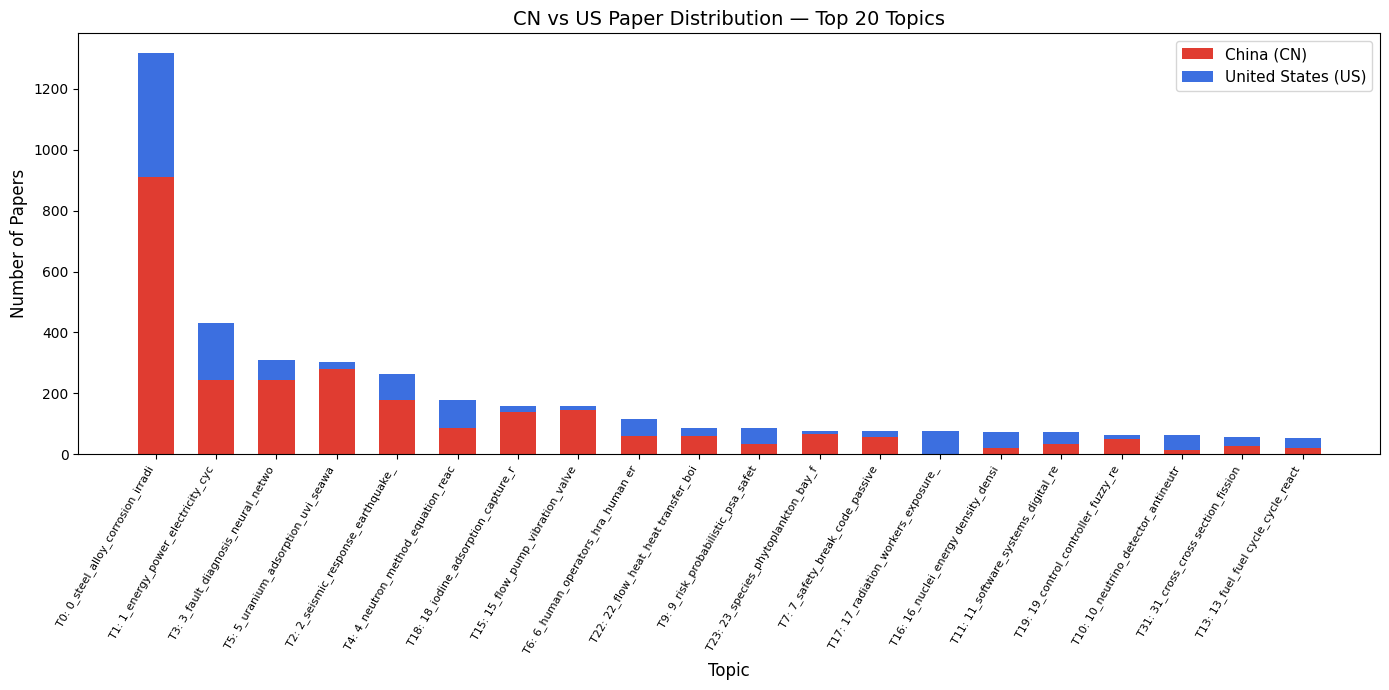

In [11]:
# ── 6.4 Stacked bar chart: CN vs US topic distribution ───────────────────────
top_k = topic_country_matrix.head(TOP_K_TOPICS).copy()

# Merge topic names for labels
name_map = dict(zip(topic_info_export["topic_id"], topic_info_export["name"]))
labels = [f"T{tid}: {name_map.get(tid, '')[:30]}" for tid in top_k.index]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(labels))
width = 0.6

bars_cn = ax.bar(x, top_k["CN"], width, label="China (CN)", color="#E03C31")
bars_us = ax.bar(x, top_k["US"], width, bottom=top_k["CN"], label="United States (US)", color="#3C6FE0")

ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("Number of Papers", fontsize=12)
ax.set_title(f"CN vs US Paper Distribution — Top {TOP_K_TOPICS} Topics", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
ax.legend(fontsize=11)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "cn_us_topic_distribution.png")
fig.savefig(fig_path, dpi=200)
print(f"✅ Saved {fig_path}")
plt.show()

# 7. Gap Metrics (basic)
Quantify the CN–US technology gap using **topic coverage** and **Jensen-Shannon divergence** of topic distributions.

In [12]:
# ── 7.1 Coverage ─────────────────────────────────────────────────────────────
all_topics_set = set(df_cn_us_valid["topic"].unique())
cn_topics = set(df_cn_us_valid.loc[df_cn_us_valid["country_code"] == "CN", "topic"].unique())
us_topics = set(df_cn_us_valid.loc[df_cn_us_valid["country_code"] == "US", "topic"].unique())

cn_coverage = len(cn_topics) / len(all_topics_set) if all_topics_set else 0
us_coverage = len(us_topics) / len(all_topics_set) if all_topics_set else 0
cn_only = cn_topics - us_topics
us_only = us_topics - cn_topics

print("── Topic Coverage ──")
print(f"  Total topics (CN∪US, excl noise): {len(all_topics_set)}")
print(f"  CN covers: {len(cn_topics)} topics  ({cn_coverage:.2%})")
print(f"  US covers: {len(us_topics)} topics  ({us_coverage:.2%})")
print(f"  CN-only topics: {sorted(cn_only) if cn_only else '(none)'}")
print(f"  US-only topics: {sorted(us_only) if us_only else '(none)'}")

# ── 7.2 Jensen-Shannon Divergence ───────────────────────────────────────────
# Build probability distributions over all topics for CN and US
all_topic_ids = sorted(all_topics_set)
cn_counts = topic_country_matrix.reindex(all_topic_ids)["CN"].fillna(0).values.astype(float)
us_counts = topic_country_matrix.reindex(all_topic_ids)["US"].fillna(0).values.astype(float)

# Normalise to probability distributions
p_cn = cn_counts / cn_counts.sum() if cn_counts.sum() > 0 else cn_counts
p_us = us_counts / us_counts.sum() if us_counts.sum() > 0 else us_counts

js_div = jensenshannon(p_cn, p_us)   # returns the JS *distance* (sqrt of divergence)
js_divergence = js_div ** 2           # actual divergence

print(f"\n── Structure Divergence ──")
print(f"  JS distance  (√divergence): {js_div:.4f}")
print(f"  JS divergence:              {js_divergence:.4f}")
print(f"  (0 = identical distributions; 1 = maximally different)")

# ── 7.3 Export metrics ──────────────────────────────────────────────────────
metrics = {
    "n_topics_total": int(len(all_topics_set)),
    "cn_topic_count": int(len(cn_topics)),
    "us_topic_count": int(len(us_topics)),
    "cn_coverage": round(float(cn_coverage), 4),
    "us_coverage": round(float(us_coverage), 4),
    "cn_only_topics": [int(t) for t in sorted(cn_only)],
    "us_only_topics": [int(t) for t in sorted(us_only)],
    "js_distance": round(float(js_div), 6),
    "js_divergence": round(float(js_divergence), 6),
    "cn_total_papers": int(cn_counts.sum()),
    "us_total_papers": int(us_counts.sum()),
}

metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\n✅ Exported {metrics_path}")


── Topic Coverage ──
  Total topics (CN∪US, excl noise): 63
  CN covers: 61 topics  (96.83%)
  US covers: 63 topics  (100.00%)
  CN-only topics: (none)
  US-only topics: [np.int64(21), np.int64(43)]

── Structure Divergence ──
  JS distance  (√divergence): 0.3328
  JS divergence:              0.1107
  (0 = identical distributions; 1 = maximally different)

✅ Exported output/cluster_results/metrics.json


# 8. Visualizations
Generate BERTopic interactive topic map (HTML), a UMAP 2-D scatter plot coloured by topic, and the topic hierarchy.

In [13]:
# ── 8.1 BERTopic interactive topic map (HTML) ────────────────────────────────
try:
    fig_topics = topic_model.visualize_topics()
    html_path = os.path.join(OUTPUT_DIR, "topic_map.html")
    fig_topics.write_html(html_path)
    print(f"✅ Saved interactive topic map → {html_path}")
except Exception as e:
    print(f"⚠️  visualize_topics() failed ({e}); will use UMAP scatter fallback.")

✅ Saved interactive topic map → output/cluster_results/topic_map.html


Computing 2-D UMAP projection for scatter plot…
✅ Saved output/cluster_results/umap_scatter.png


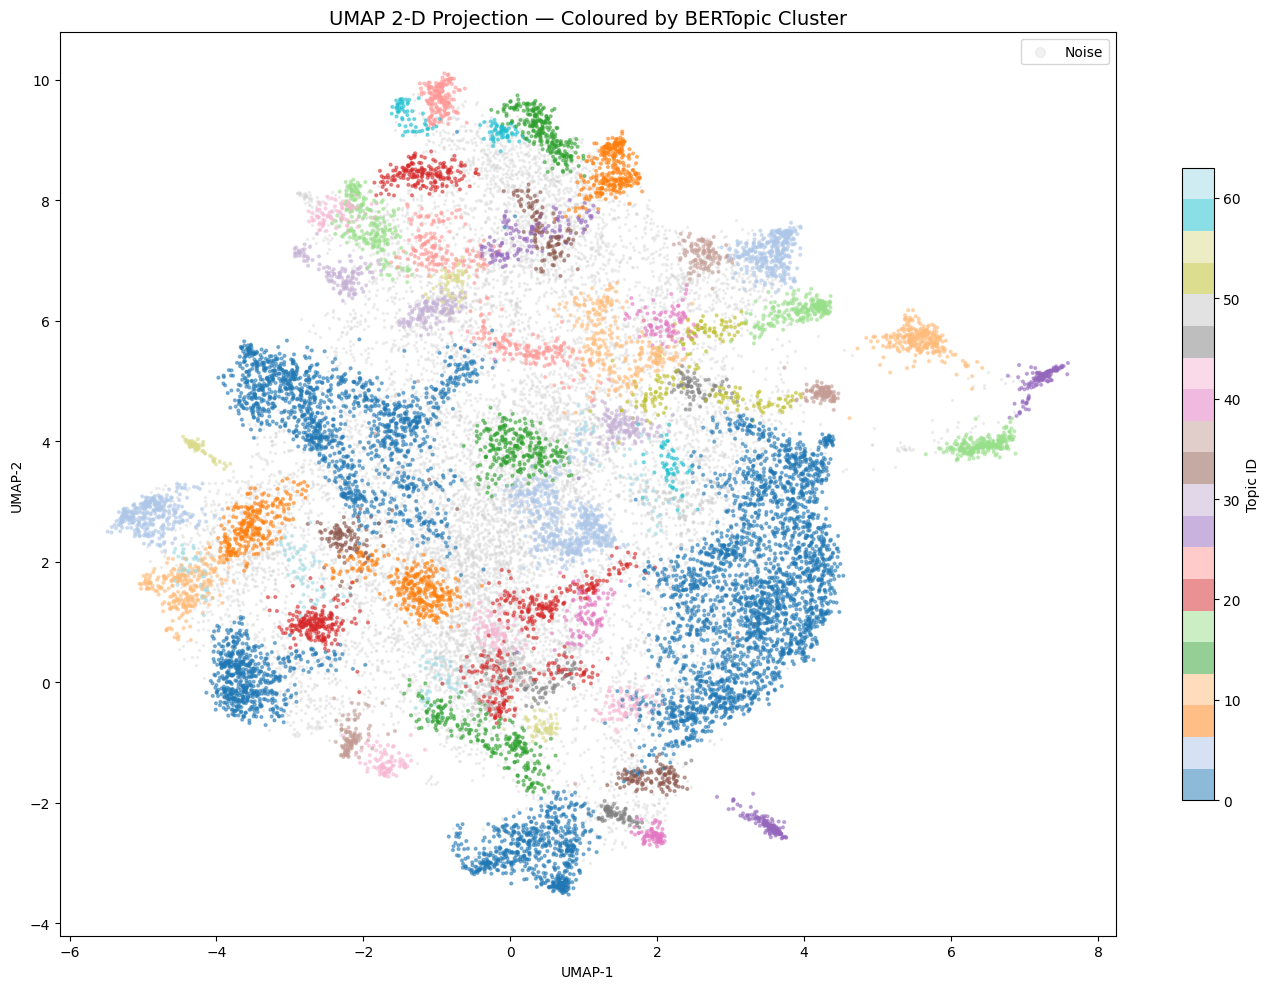

In [14]:
# ── 8.2 UMAP 2-D scatter plot (matplotlib fallback / complementary) ──────────
print("Computing 2-D UMAP projection for scatter plot…")
umap_2d = UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    n_components=2,
    min_dist=0.3,
    metric=UMAP_METRIC,
    random_state=SEED,
)
xy = umap_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(14, 10))

# Separate noise vs assigned
mask_noise = np.array(topics) == -1
mask_valid = ~mask_noise

# Plot noise in light grey
ax.scatter(
    xy[mask_noise, 0], xy[mask_noise, 1],
    c="lightgrey", s=2, alpha=0.3, label="Noise"
)

# Plot assigned topics with colour map
scatter = ax.scatter(
    xy[mask_valid, 0], xy[mask_valid, 1],
    c=np.array(topics)[mask_valid],
    cmap="tab20", s=4, alpha=0.5,
)

ax.set_title("UMAP 2-D Projection — Coloured by BERTopic Cluster", fontsize=14)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="upper right", markerscale=5)
plt.colorbar(scatter, ax=ax, label="Topic ID", shrink=0.7)
plt.tight_layout()

scatter_path = os.path.join(OUTPUT_DIR, "umap_scatter.png")
fig.savefig(scatter_path, dpi=200)
print(f"✅ Saved {scatter_path}")
plt.show()

In [15]:
# ── 8.3 Topic hierarchy (optional) ───────────────────────────────────────────
try:
    fig_hier = topic_model.visualize_hierarchy()
    hier_path = os.path.join(OUTPUT_DIR, "topic_hierarchy.html")
    fig_hier.write_html(hier_path)
    print(f"✅ Saved topic hierarchy → {hier_path}")
except Exception as e:
    print(f"⚠️  visualize_hierarchy() skipped: {e}")

# ── 8.4 Bar chart of top topic keywords ─────────────────────────────────────
try:
    fig_bar = topic_model.visualize_barchart(top_n_topics=TOP_K_TOPICS)
    bar_path = os.path.join(OUTPUT_DIR, "topic_barchart.html")
    fig_bar.write_html(bar_path)
    print(f"✅ Saved topic barchart → {bar_path}")
except Exception as e:
    print(f"⚠️  visualize_barchart() skipped: {e}")

✅ Saved topic hierarchy → output/cluster_results/topic_hierarchy.html
✅ Saved topic barchart → output/cluster_results/topic_barchart.html


# 9. Topic Reduction (optional)
If the initial model produces too many fine-grained topics, use `reduce_topics()` to merge similar ones.

**How to choose `nr_topics`:**
- Start with the hierarchy visualisation (Section 8.3) and pick a cut level
- Or set `nr_topics="auto"` to let BERTopic decide
- Common range for scientometrics: 20–50 macro topics

In [16]:
# ── 9.1 Reduce topics (uncomment & run when needed) ──────────────────────────
# Set the desired number of topics:
NR_TOPICS_REDUCED = 30   # change as needed; or set to "auto"

# topic_model.reduce_topics(docs, nr_topics=NR_TOPICS_REDUCED)
# reduced_topics = topic_model.topics_

# print(f"Reduced to {len(set(reduced_topics)) - (1 if -1 in reduced_topics else 0)} topics (+ noise)")

# # Update the DataFrame
# df["topic_reduced"] = reduced_topics

# # Re-export reduced topic info
# reduced_info = topic_model.get_topic_info()
# reduced_rows = []
# for tid in sorted(reduced_info["Topic"].unique()):
#     kws = topic_model.get_topic(tid)
#     kw_str = ", ".join([w for w, _ in kws[:TOP_N_KEYWORDS]]) if kws else ""
#     reduced_rows.append({
#         "topic_id": tid,
#         "count": int(reduced_info.loc[reduced_info["Topic"] == tid, "Count"].values[0]),
#         "name": reduced_info.loc[reduced_info["Topic"] == tid, "Name"].values[0],
#         "top_keywords": kw_str,
#     })
# pd.DataFrame(reduced_rows).to_csv(os.path.join(OUTPUT_DIR, "topic_info_reduced.csv"), index=False)
# print("✅ Exported topic_info_reduced.csv")

# # Visualise comparison
# try:
#     fig_reduced = topic_model.visualize_barchart(top_n_topics=NR_TOPICS_REDUCED)
#     fig_reduced.write_html(os.path.join(OUTPUT_DIR, "topic_barchart_reduced.html"))
#     print("✅ Saved reduced topic barchart")
# except Exception as e:
#     print(f"⚠️  Reduced barchart skipped: {e}")

print("ℹ️  Uncomment this cell and run it to perform topic reduction.")

ℹ️  Uncomment this cell and run it to perform topic reduction.


# 10. Save Artifacts
Persist the BERTopic model, the per-paper topic assignment table, and print a summary of all generated files.

In [17]:
# ── 10.1 Save BERTopic model ──────────────────────────────────────────────────
# Patch json's default encoder to handle numpy scalar types (BERTopic internal bug)
import json as _json

_orig_default = _json.JSONEncoder.default

def _numpy_safe_default(self, obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return _orig_default(self, obj)

_json.JSONEncoder.default = _numpy_safe_default

model_dir = os.path.join(OUTPUT_DIR, "bertopic_model")
try:
    topic_model.save(model_dir, serialization="safetensors", save_ctfidf=True, save_embedding_model=SPECTER_MODEL)
    print(f"✅ BERTopic model saved → {model_dir}")
finally:
    _json.JSONEncoder.default = _orig_default   # restore

# ── 10.2 Export paper_topics.csv ─────────────────────────────────────────────
export_cols = ["paper_id", "country", "country_code", "topic", "topic_prob"]
if HAS_YEAR:
    export_cols.insert(2, "year")

paper_topics = df[export_cols].copy()
paper_topics_path = os.path.join(OUTPUT_DIR, "paper_topics.csv")
paper_topics.to_csv(paper_topics_path, index=False)
print(f"✅ Exported paper_topics.csv  ({len(paper_topics):,} rows)")

# ── 10.3 Summary of all output files ────────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  All outputs in: {os.path.abspath(OUTPUT_DIR)}")
print(f"{'═'*60}")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = "  " * (level + 1)
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"{sub_indent}{f}  ({size_mb:.2f} MB)")

print(f"\n🎉 Pipeline complete!")


✅ BERTopic model saved → output/cluster_results/bertopic_model
✅ Exported paper_topics.csv  (25,794 rows)

════════════════════════════════════════════════════════════
  All outputs in: /Users/luoyiti/Project/catch-up/output/cluster_results
════════════════════════════════════════════════════════════
cluster_results/
  cn_us_topic_distribution.png  (0.24 MB)
  metrics.json  (0.00 MB)
  paper_topics.csv  (1.53 MB)
  param_search_results.csv  (0.00 MB)
  representative_docs.json  (0.32 MB)
  specter2_embeddings_cache.npy  (75.57 MB)
  topic_barchart.html  (4.64 MB)
  topic_country_matrix.csv  (0.00 MB)
  topic_hierarchy.html  (4.65 MB)
  topic_info.csv  (0.01 MB)
  topic_info_reduced.csv  (0.00 MB)
  topic_map.html  (4.68 MB)
  topic_map_country.html  (4.66 MB)
  topic_share_country.csv  (0.00 MB)
  topic_stats_country.csv  (0.01 MB)
  umap_scatter.png  (1.82 MB)
  capability_gap/
    capability_gap_summary.json  (0.00 MB)
    capability_gap_summary.md  (0.00 MB)
    frontier_js_metrics.

# 11. Capability Gap Analysis — Config & Variable Mapping
Define all parameters for the **Frontier gap** and **Impact gap** analyses.  
Auto-detect the best topic column; standardise country labels to `{CN, US, OTHER}`; create a dedicated output sub-directory.

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell A — Config & Variable Mapping
# ══════════════════════════════════════════════════════════════════════════════

# ── Auto-detect the best topic column ────────────────────────────────────────
_topic_candidates = ["topic_reduced", "topic_reassign", "topic"]
TOPIC_COL = None
for _c in _topic_candidates:
    if _c in df.columns and df[_c].notna().any():
        TOPIC_COL = _c
        break
if TOPIC_COL is None:
    raise ValueError("No topic column found in df. Run BERTopic clustering first.")
print(f"✅ TOPIC_COL = '{TOPIC_COL}'")

# ── Column aliases ───────────────────────────────────────────────────────────
CIT_COL     = "citation"
YEAR_COL    = "year"
COUNTRY_COL = "country_code"   # populated in Section 1

# ── Analysis parameters ──────────────────────────────────────────────────────
WINDOW_YEARS         = 5      # recent-year window for Frontier_B
EXCLUDE_RECENT_YEARS = 1      # drop most recent N year(s) — citation window too short
MIN_BUCKET_SIZE      = 20     # min papers in (topic, year) bucket to compute q90
MIN_FRONTIER_US      = 20     # min US-frontier papers per topic for centroid calc
TOPK_REPORT          = 20     # top-K topics shown in charts / reports

# ── Country label lists (for safety, re-normalise) ──────────────────────────
COUNTRY_US = ["United States", "US", "USA", "United States of America", "united states"]
COUNTRY_CN = ["China", "CN", "PRC", "Peoples R China", "china", "CHINA"]

def _map_country2(c):
    """Map raw country / country_code to {CN, US, OTHER}."""
    if c in COUNTRY_CN or c == "CN":
        return "CN"
    if c in COUNTRY_US or c == "US":
        return "US"
    return "OTHER"

df["country2"] = df[COUNTRY_COL].apply(_map_country2)

# ── Output directory for capability-gap analysis ────────────────────────────
CAP_DIR = os.path.join(OUTPUT_DIR, "capability_gap")
os.makedirs(CAP_DIR, exist_ok=True)

# ── Report ───────────────────────────────────────────────────────────────────
print(f"TOPIC_COL            = {TOPIC_COL}")
print(f"CIT_COL              = {CIT_COL}")
print(f"YEAR_COL             = {YEAR_COL}")
print(f"COUNTRY_COL          = {COUNTRY_COL}")
print(f"WINDOW_YEARS         = {WINDOW_YEARS}")
print(f"EXCLUDE_RECENT_YEARS = {EXCLUDE_RECENT_YEARS}")
print(f"MIN_BUCKET_SIZE      = {MIN_BUCKET_SIZE}")
print(f"MIN_FRONTIER_US      = {MIN_FRONTIER_US}")
print(f"TOPK_REPORT          = {TOPK_REPORT}")
print(f"CAP_DIR              = {CAP_DIR}")
print(f"\ncountry2 distribution:")
print(df["country2"].value_counts().to_string())

✅ TOPIC_COL = 'topic'
TOPIC_COL            = topic
CIT_COL              = citation
YEAR_COL             = year
COUNTRY_COL          = country_code
WINDOW_YEARS         = 5
EXCLUDE_RECENT_YEARS = 1
MIN_BUCKET_SIZE      = 20
MIN_FRONTIER_US      = 20
TOPK_REPORT          = 20
CAP_DIR              = output/cluster_results/capability_gap

country2 distribution:
country2
OTHER    16728
CN        5687
US        3379


## 11.1 Data Checks
Verify paper counts by country, year distribution, citation missingness, and topic noise ratio before proceeding.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Data Checks
# ══════════════════════════════════════════════════════════════════════════════

print(f"Total papers (N):  {len(df):,}")
print(f"CN papers:         {(df['country2']=='CN').sum():,}")
print(f"US papers:         {(df['country2']=='US').sum():,}")
print(f"OTHER papers:      {(df['country2']=='OTHER').sum():,}")

print(f"\n── Year distribution ──")
if YEAR_COL in df.columns:
    print(df[YEAR_COL].value_counts().sort_index().to_string())
else:
    print("  (no year column)")

print(f"\n── Citation column: {CIT_COL} ──")
cit_missing = df[CIT_COL].isna().sum()
print(f"  Missing: {cit_missing:,} ({cit_missing/len(df):.2%})")
print(f"  Mean:    {df[CIT_COL].mean():.2f}")
print(f"  Median:  {df[CIT_COL].median():.1f}")

print(f"\n── Topic column: {TOPIC_COL} ──")
noise_n = (df[TOPIC_COL] == -1).sum()
print(f"  Noise (topic = -1): {noise_n:,}  ({noise_n/len(df):.2%})")
print(f"  Valid topics:       {df[df[TOPIC_COL] != -1][TOPIC_COL].nunique()}")
print(f"  Embeddings shape:   {embeddings.shape}")

Total papers (N):  25,794
CN papers:         5,687
US papers:         3,379
OTHER papers:      16,728

── Year distribution ──
year
1990      57
1991     243
1992     205
1993     247
1994     254
1995     229
1996     265
1997     258
1998     261
1999     277
2000     277
2001     259
2002     251
2003     266
2004     249
2005     283
2006     350
2007     354
2008     459
2009     483
2010     517
2011     710
2012     785
2013     917
2014     993
2015     953
2016    1039
2017    1125
2018    1157
2019    1244
2020    1440
2021    1584
2022    1735
2023    1770
2024    2035
2025    2117
2026     146

── Citation column: citation ──
  Missing: 0 (0.00%)
  Mean:    15.25
  Median:  6.0

── Topic column: topic ──
  Noise (topic = -1): 11,495  (44.56%)
  Valid topics:       64
  Embeddings shape:   (25794, 768)


## 11.2 Normalised Citations (MNCS-style)
For each paper $i$ in bucket $(topic, year)$:

$$nc_i = \frac{c_i + 1}{E[c \mid topic, year] + 1}$$

The $+1$ smoothing avoids zero-division and dampens low-citation noise.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Build Normalised Citations (MNCS-style)
# nc_i = (c_i + 1) / (E[c | topic, year] + 1)
# ══════════════════════════════════════════════════════════════════════════════

# ── Work on non-noise papers with valid citations & years ────────────────────
_mask_valid = (
    (df[TOPIC_COL] != -1)
    & df[CIT_COL].notna()
    & df[YEAR_COL].notna()
)
df_valid = df[_mask_valid].copy()
print(f"Papers with valid topic + citation + year: {len(df_valid):,}")

# ── Bucket key: (topic, year) ────────────────────────────────────────────────
df_valid["_topic"] = df_valid[TOPIC_COL].astype(int)
df_valid["_year"]  = df_valid[YEAR_COL].astype(int)
df_valid["bucket_key"] = list(zip(df_valid["_topic"], df_valid["_year"]))

# ── Expected citations per bucket ────────────────────────────────────────────
bucket_stats = (
    df_valid
    .groupby("bucket_key")[CIT_COL]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "expected_mean", "median": "expected_median",
                      "count": "bucket_size"})
)
df_valid = df_valid.join(bucket_stats, on="bucket_key")

# ── Normalised citation ──────────────────────────────────────────────────────
df_valid["nc"] = (df_valid[CIT_COL] + 1) / (df_valid["expected_mean"] + 1)

print(f"\n── Bucket statistics ──")
print(f"  Total buckets (topic, year):   {len(bucket_stats):,}")
print(f"  Small buckets (< {MIN_BUCKET_SIZE}):  "
      f"{(bucket_stats['bucket_size'] < MIN_BUCKET_SIZE).sum():,}")
print(f"  nc — mean: {df_valid['nc'].mean():.3f},  median: {df_valid['nc'].median():.3f}")

# ── Export ────────────────────────────────────────────────────────────────────
export_nc = df_valid[["paper_id", "country2", YEAR_COL, TOPIC_COL, CIT_COL,
                       "nc", "expected_mean", "expected_median",
                       "bucket_size"]].copy()
export_nc.to_csv(os.path.join(CAP_DIR, "paper_norm_citations.csv"), index=False)
print(f"✅ Exported paper_norm_citations.csv  ({len(export_nc):,} rows)")

Papers with valid topic + citation + year: 14,299

── Bucket statistics ──
  Total buckets (topic, year):   1,724
  Small buckets (< 20):  1,587
  nc — mean: 1.000,  median: 0.711
✅ Exported paper_norm_citations.csv  (14,299 rows)


## 11.3 Top-10 % Flag (PP(top10 %)-style)
Within each $(topic, year)$ bucket, compute the 90th-percentile citation threshold $q_{90}$.  
A paper is **top-10 %** if $c_i \geq q_{90}$. Buckets with fewer than `MIN_BUCKET_SIZE` papers are skipped.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Top-10 % Flag per Bucket
# ══════════════════════════════════════════════════════════════════════════════

# ── q90 threshold per bucket (only large-enough buckets) ─────────────────────
bucket_q90 = (
    df_valid[df_valid["bucket_size"] >= MIN_BUCKET_SIZE]
    .groupby("bucket_key")[CIT_COL]
    .quantile(0.9)
    .rename("q90")
)

# Track skipped buckets
skipped_buckets = set(df_valid["bucket_key"].unique()) - set(bucket_q90.index)
n_skipped_papers = df_valid[df_valid["bucket_key"].isin(skipped_buckets)].shape[0]
print(f"Skipped small buckets: {len(skipped_buckets):,}  "
      f"({n_skipped_papers:,} papers affected)")

# ── Merge q90 & assign flag ─────────────────────────────────────────────────
df_valid = df_valid.join(bucket_q90, on="bucket_key")
df_valid["top10_flag"] = False
_has_q90 = df_valid["q90"].notna()
df_valid.loc[_has_q90, "top10_flag"] = (
    df_valid.loc[_has_q90, CIT_COL] >= df_valid.loc[_has_q90, "q90"]
)

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"\n── Top-10 % Summary (eligible buckets only) ──")
_eligible = df_valid[_has_q90]
print(f"  Eligible papers:  {len(_eligible):,}")
print(f"  Top-10 % papers:  {_eligible['top10_flag'].sum():,}  "
      f"({_eligible['top10_flag'].mean():.2%})")
for c in ["CN", "US"]:
    _sub = _eligible[_eligible["country2"] == c]
    if len(_sub) > 0:
        pct = _sub["top10_flag"].mean()
        print(f"  {c} top-10 %:  {_sub['top10_flag'].sum():,} / {len(_sub):,}  = {pct:.2%}")

# ── Export ────────────────────────────────────────────────────────────────────
export_t10 = df_valid[["paper_id", "country2", YEAR_COL, TOPIC_COL, CIT_COL,
                        "nc", "q90", "top10_flag", "bucket_size"]].copy()
export_t10.to_csv(os.path.join(CAP_DIR, "paper_top10_flag.csv"), index=False)
print(f"\n✅ Exported paper_top10_flag.csv  ({len(export_t10):,} rows)")

Skipped small buckets: 1,587  (7,853 papers affected)

── Top-10 % Summary (eligible buckets only) ──
  Eligible papers:  6,446
  Top-10 % papers:  747  (11.59%)
  CN top-10 %:  282 / 2,161  = 13.05%
  US top-10 %:  139 / 767  = 18.12%

✅ Exported paper_top10_flag.csv  (14,299 rows)


## 11.4 Define Frontier Sets
Two definitions:

| Frontier | Scope |
|----------|-------|
| **A** (all-period) | Every top-10 % paper up to `max_year − EXCLUDE_RECENT_YEARS` |
| **B** (recent, **default**) | Top-10 % papers within a `WINDOW_YEARS`-year sliding window ending at `max_year − EXCLUDE_RECENT_YEARS` |

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — Define Frontier Sets (A: all-period, B: recent window)
# ══════════════════════════════════════════════════════════════════════════════

max_year = int(df_valid[YEAR_COL].max())
frontier_year_end   = max_year - EXCLUDE_RECENT_YEARS
frontier_year_start = frontier_year_end - WINDOW_YEARS + 1

print(f"max year in data:          {max_year}")
print(f"EXCLUDE_RECENT_YEARS:      {EXCLUDE_RECENT_YEARS}")
print(f"Frontier_B window:         {frontier_year_start} – {frontier_year_end}")
print(f"Frontier_A window:         all years  ≤ {frontier_year_end}")

# ── Frontier_A: all-period top10 % (up to frontier_year_end) ─────────────────
mask_A = (df_valid["top10_flag"]) & (df_valid["_year"] <= frontier_year_end)
df_valid["frontier_A"] = mask_A

# ── Frontier_B: recent-window top10 % (DEFAULT) ─────────────────────────────
mask_B = (
    (df_valid["top10_flag"])
    & (df_valid["_year"] >= frontier_year_start)
    & (df_valid["_year"] <= frontier_year_end)
)
df_valid["frontier_B"] = mask_B

print(f"\nFrontier_A papers: {mask_A.sum():,}")
print(f"Frontier_B papers: {mask_B.sum():,}")
for c in ["CN", "US"]:
    _fa = ((df_valid["country2"] == c) & df_valid["frontier_A"]).sum()
    _fb = ((df_valid["country2"] == c) & df_valid["frontier_B"]).sum()
    print(f"  {c}  Frontier_A={_fa:,}   Frontier_B={_fb:,}")

# ── Export ────────────────────────────────────────────────────────────────────
frontier_cols = ["paper_id", "country2", YEAR_COL, TOPIC_COL, CIT_COL,
                 "nc", "top10_flag", "frontier_A", "frontier_B"]
export_fr = df_valid[df_valid["frontier_A"] | df_valid["frontier_B"]][frontier_cols].copy()
export_fr["frontier_type"] = "none"
export_fr.loc[
    df_valid.loc[export_fr.index, "frontier_A"] & ~df_valid.loc[export_fr.index, "frontier_B"],
    "frontier_type"
] = "A_only"
export_fr.loc[
    ~df_valid.loc[export_fr.index, "frontier_A"] & df_valid.loc[export_fr.index, "frontier_B"],
    "frontier_type"
] = "B_only"
export_fr.loc[
    df_valid.loc[export_fr.index, "frontier_A"] & df_valid.loc[export_fr.index, "frontier_B"],
    "frontier_type"
] = "A_and_B"
export_fr.to_csv(os.path.join(CAP_DIR, "frontier_papers.csv"), index=False)
print(f"\n✅ Exported frontier_papers.csv  ({len(export_fr):,} rows)")

max year in data:          2026
EXCLUDE_RECENT_YEARS:      1
Frontier_B window:         2021 – 2025
Frontier_A window:         all years  ≤ 2025

Frontier_A papers: 747
Frontier_B papers: 375
  CN  Frontier_A=282   Frontier_B=211
  US  Frontier_A=139   Frontier_B=36

✅ Exported frontier_papers.csv  (747 rows)


## 11.5 Frontier Topic-Distribution Gap
Compare the topic distributions of **US frontier** vs **CN frontier** papers using:
- Jensen–Shannon distance $JS_d = \sqrt{JSD}$ and divergence $JSD = JS_d^2$
- Per-topic delta $\Delta_F(t) = P_{USF}(t) - P_{CNF}(t)$

US frontier papers (excl noise): 36
CN frontier papers (excl noise): 211

Frontier JS distance  (√JSD): 0.3879
Frontier JS divergence (JSD): 0.1505
✅ Exported frontier_topic_distribution.csv
✅ Exported frontier_js_metrics.json
✅ Saved output/cluster_results/capability_gap/frontier_topic_distribution.png


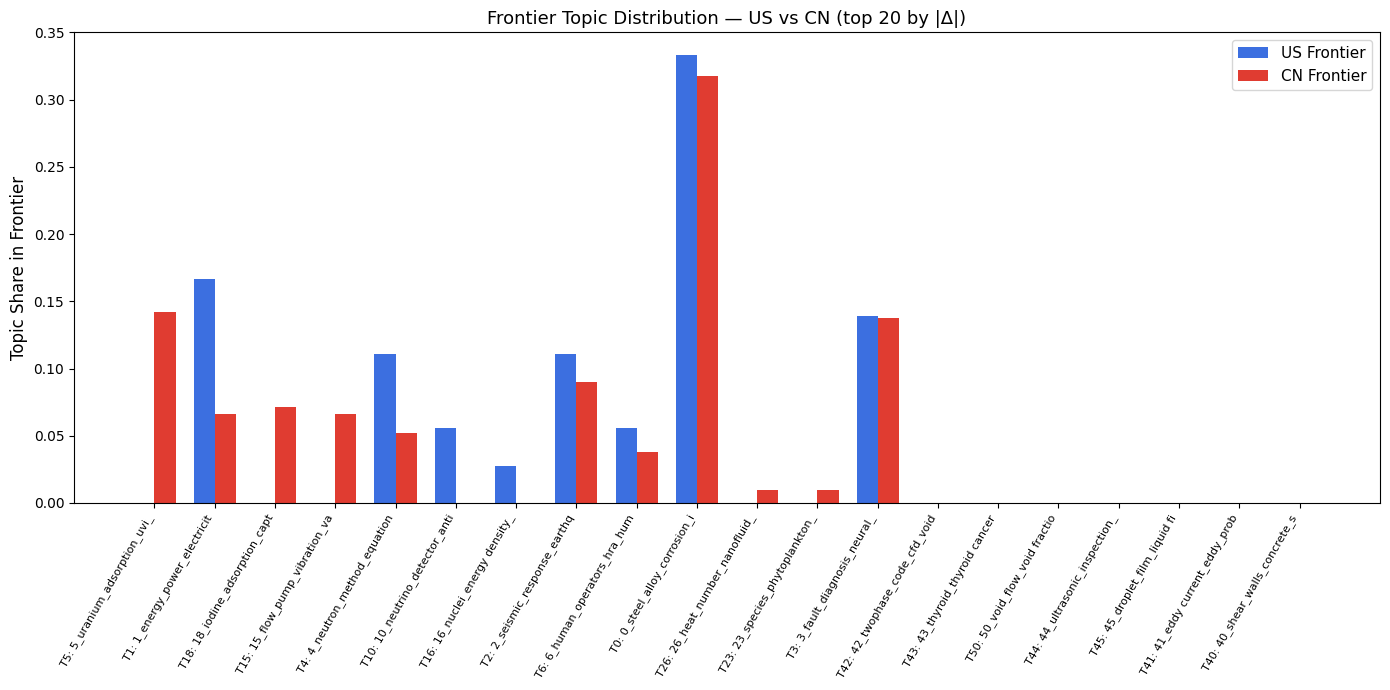

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — Frontier Topic-Distribution Gap (uses Frontier_B by default)
# ══════════════════════════════════════════════════════════════════════════════
FRONTIER_COL = "frontier_B"   # switch to "frontier_A" for all-period

# ── Filter: CN & US frontier papers, exclude noise topic ────────────────────
df_fr = df_valid[(df_valid[FRONTIER_COL]) & (df_valid[TOPIC_COL] != -1)].copy()
df_fr_us = df_fr[df_fr["country2"] == "US"]
df_fr_cn = df_fr[df_fr["country2"] == "CN"]
print(f"US frontier papers (excl noise): {len(df_fr_us):,}")
print(f"CN frontier papers (excl noise): {len(df_fr_cn):,}")

# ── Topic distributions ──────────────────────────────────────────────────────
all_valid_topics = sorted(df_valid[df_valid[TOPIC_COL] != -1][TOPIC_COL].unique())
us_fr_counts = df_fr_us[TOPIC_COL].value_counts().reindex(all_valid_topics, fill_value=0)
cn_fr_counts = df_fr_cn[TOPIC_COL].value_counts().reindex(all_valid_topics, fill_value=0)

p_usf = (us_fr_counts / us_fr_counts.sum()).values.astype(float)
p_cnf = (cn_fr_counts / cn_fr_counts.sum()).values.astype(float)

# ── JS distance & divergence (scipy jensenshannon returns √JSD) ─────────────
from scipy.spatial.distance import jensenshannon as _jsd
js_dist_frontier = float(_jsd(p_usf, p_cnf))
jsd_frontier     = js_dist_frontier ** 2
print(f"\nFrontier JS distance  (√JSD): {js_dist_frontier:.4f}")
print(f"Frontier JS divergence (JSD): {jsd_frontier:.4f}")

# ── Topic-wise delta ─────────────────────────────────────────────────────────
frontier_topic_dist = pd.DataFrame({
    "topic": all_valid_topics,
    "P_USF": p_usf,
    "P_CNF": p_cnf,
    "delta_F": p_usf - p_cnf,   # positive → US frontier larger share
})
# Merge topic names
_name_map = dict(zip(topic_info_export["topic_id"], topic_info_export["name"]))
frontier_topic_dist["topic_name"] = frontier_topic_dist["topic"].map(_name_map)
frontier_topic_dist = frontier_topic_dist.sort_values("delta_F", key=abs, ascending=False)
frontier_topic_dist.to_csv(
    os.path.join(CAP_DIR, "frontier_topic_distribution.csv"), index=False)
print(f"✅ Exported frontier_topic_distribution.csv")

# ── Metrics JSON ─────────────────────────────────────────────────────────────
js_metrics = {
    "frontier_type": FRONTIER_COL,
    "frontier_window": f"{frontier_year_start}-{frontier_year_end}",
    "us_frontier_papers": int(len(df_fr_us)),
    "cn_frontier_papers": int(len(df_fr_cn)),
    "js_distance_frontier": round(js_dist_frontier, 6),
    "jsd_frontier": round(jsd_frontier, 6),
}
with open(os.path.join(CAP_DIR, "frontier_js_metrics.json"), "w") as f:
    json.dump(js_metrics, f, indent=2)
print(f"✅ Exported frontier_js_metrics.json")

# ── Bar chart: US vs CN frontier topic distribution (top K by |Δ|) ───────────
_top = frontier_topic_dist.head(TOPK_REPORT).copy()
_labels = [f"T{int(t)}: {str(n)[:25]}" for t, n in zip(_top["topic"], _top["topic_name"])]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(_labels))
w = 0.35
ax.bar(x - w / 2, _top["P_USF"], w, label="US Frontier", color="#3C6FE0")
ax.bar(x + w / 2, _top["P_CNF"], w, label="CN Frontier", color="#E03C31")
ax.set_xticks(x)
ax.set_xticklabels(_labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Topic Share in Frontier", fontsize=12)
ax.set_title(f"Frontier Topic Distribution — US vs CN (top {TOPK_REPORT} by |Δ|)",
             fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
_path = os.path.join(CAP_DIR, "frontier_topic_distribution.png")
fig.savefig(_path, dpi=200)
print(f"✅ Saved {_path}")
plt.show()

## 11.6 Frontier Semantic Distance Gap (Centre-based)
For each topic $t$ with enough US frontier papers:

1. Compute the US-frontier centroid $\mu_{USF,t}$ (mean of L2-normed SPECTER2 embeddings, then re-normalise).
2. $D_{CN}(t) = \text{mean}_{i \in CN,t}\bigl(1 - \cos(e_i, \mu_{USF,t})\bigr)$
3. $D_{US}(t) = \text{mean}_{i \in US,t}\bigl(1 - \cos(e_i, \mu_{USF,t})\bigr)$
4. $\text{Gap}(t) = D_{CN}(t) - D_{US}(t)$   *(positive → CN farther from frontier)*

Topics computed: 0
Topics skipped:  64
  Skipped IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]…

✅ Exported frontier_semantic_gap_by_topic.csv
✅ Saved output/cluster_results/capability_gap/frontier_semantic_gap_by_topic.png


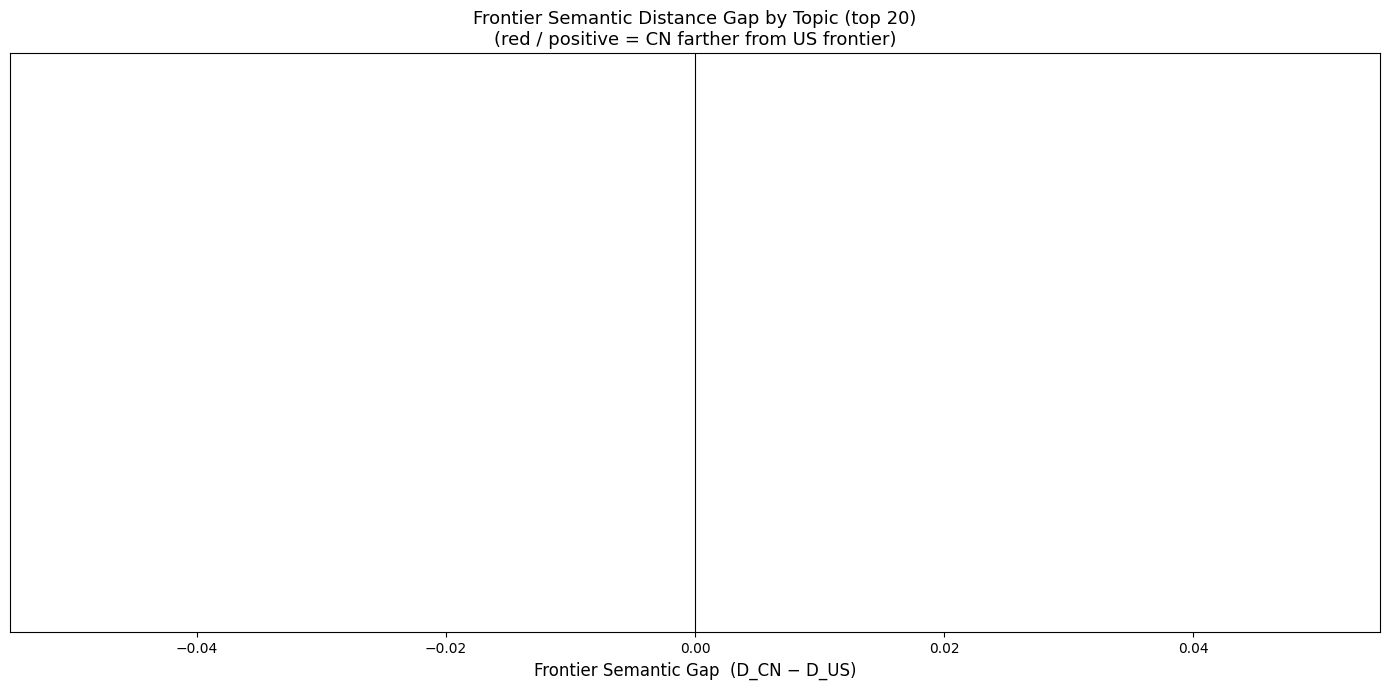

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Frontier Semantic Distance Gap (Centre-based, per topic)
# ══════════════════════════════════════════════════════════════════════════════

# Embeddings are already L2-normed (Section 2) — verify / re-norm for safety
emb_norm = normalize(embeddings, norm="l2")

FRONTIER_COL_SEM = "frontier_B"

results_sem = []
skipped_topics_sem = []

for t in sorted(df_valid[df_valid[TOPIC_COL] != -1][TOPIC_COL].unique()):
    # US frontier in topic t
    mask_us_fr = (
        (df_valid["country2"] == "US")
        & (df_valid[TOPIC_COL] == t)
        & (df_valid[FRONTIER_COL_SEM])
    )
    idx_us_fr = df_valid[mask_us_fr].index.values

    if len(idx_us_fr) < MIN_FRONTIER_US:
        skipped_topics_sem.append(t)
        results_sem.append({
            "topic": int(t),
            "n_us_frontier": int(len(idx_us_fr)),
            "n_cn_topic": 0, "n_us_topic": 0,
            "D_CN": np.nan, "D_US": np.nan,
            "gap_frontier_semantic": np.nan,
            "skipped": True,
            "reason": f"US frontier < {MIN_FRONTIER_US}",
        })
        continue

    # ── Centroid of US frontier (L2 re-normalise the mean) ───────────────
    centroid_usf = emb_norm[idx_us_fr].mean(axis=0)
    centroid_usf /= np.linalg.norm(centroid_usf) + 1e-10

    # CN papers in topic t (all papers, not just frontier)
    mask_cn_t = (df_valid["country2"] == "CN") & (df_valid[TOPIC_COL] == t)
    idx_cn = df_valid[mask_cn_t].index.values

    # US papers in topic t
    mask_us_t = (df_valid["country2"] == "US") & (df_valid[TOPIC_COL] == t)
    idx_us = df_valid[mask_us_t].index.values

    # Distance = 1 − cosine_similarity
    D_CN = float(1 - (emb_norm[idx_cn] @ centroid_usf).mean()) if len(idx_cn) > 0 else np.nan
    D_US = float(1 - (emb_norm[idx_us] @ centroid_usf).mean()) if len(idx_us) > 0 else np.nan
    gap  = (D_CN - D_US) if not (np.isnan(D_CN) or np.isnan(D_US)) else np.nan

    results_sem.append({
        "topic": int(t),
        "n_us_frontier": int(len(idx_us_fr)),
        "n_cn_topic": int(len(idx_cn)),
        "n_us_topic": int(len(idx_us)),
        "D_CN": round(D_CN, 6) if not np.isnan(D_CN) else np.nan,
        "D_US": round(D_US, 6) if not np.isnan(D_US) else np.nan,
        "gap_frontier_semantic": round(gap, 6) if not (isinstance(gap, float) and np.isnan(gap)) else np.nan,
        "skipped": False,
    })

semantic_gap_df = pd.DataFrame(results_sem)
semantic_gap_df["topic_name"] = semantic_gap_df["topic"].map(_name_map)

print(f"Topics computed: {(~semantic_gap_df['skipped']).sum()}")
print(f"Topics skipped:  {semantic_gap_df['skipped'].sum()}")
if skipped_topics_sem:
    print(f"  Skipped IDs: {skipped_topics_sem[:20]}{'…' if len(skipped_topics_sem) > 20 else ''}")

semantic_gap_df.to_csv(
    os.path.join(CAP_DIR, "frontier_semantic_gap_by_topic.csv"), index=False)
print(f"\n✅ Exported frontier_semantic_gap_by_topic.csv")

# ── Bar chart: Frontier semantic gap (top K topics) ──────────────────────────
_plot = (
    semantic_gap_df[~semantic_gap_df["skipped"]]
    .dropna(subset=["gap_frontier_semantic"])
    .sort_values("gap_frontier_semantic", key=abs, ascending=False)
    .head(TOPK_REPORT)
)
_labels = [f"T{int(t)}: {str(n)[:25]}" for t, n in zip(_plot["topic"], _plot["topic_name"])]
colors = ["#E03C31" if g > 0 else "#3C6FE0" for g in _plot["gap_frontier_semantic"]]

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(_labels)), _plot["gap_frontier_semantic"].values, color=colors)
ax.set_yticks(range(len(_labels)))
ax.set_yticklabels(_labels, fontsize=9)
ax.set_xlabel("Frontier Semantic Gap  (D_CN − D_US)", fontsize=12)
ax.set_title(
    f"Frontier Semantic Distance Gap by Topic (top {TOPK_REPORT})\n"
    "(red / positive = CN farther from US frontier)",
    fontsize=13,
)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
_path = os.path.join(CAP_DIR, "frontier_semantic_gap_by_topic.png")
fig.savefig(_path, dpi=200)
print(f"✅ Saved {_path}")
plt.show()

## 11.7 Impact Gap by Topic
Two complementary indicators per topic $t$:

| Indicator | Formula | Interpretation |
|-----------|---------|----------------|
| **MNCS** | $\overline{nc}_{country,t}$ | Mean normalised citations — overall impact |
| **PP(top 10 %)** | share of top-10 % papers | Excellence / breakthrough capacity |

$\text{Gap}(t) = \text{US}(t) - \text{CN}(t)$  *(positive → US leads)*

✅ Exported topic_impact_gap.csv  (63 topics)
✅ Saved impact_gap_mncs.png


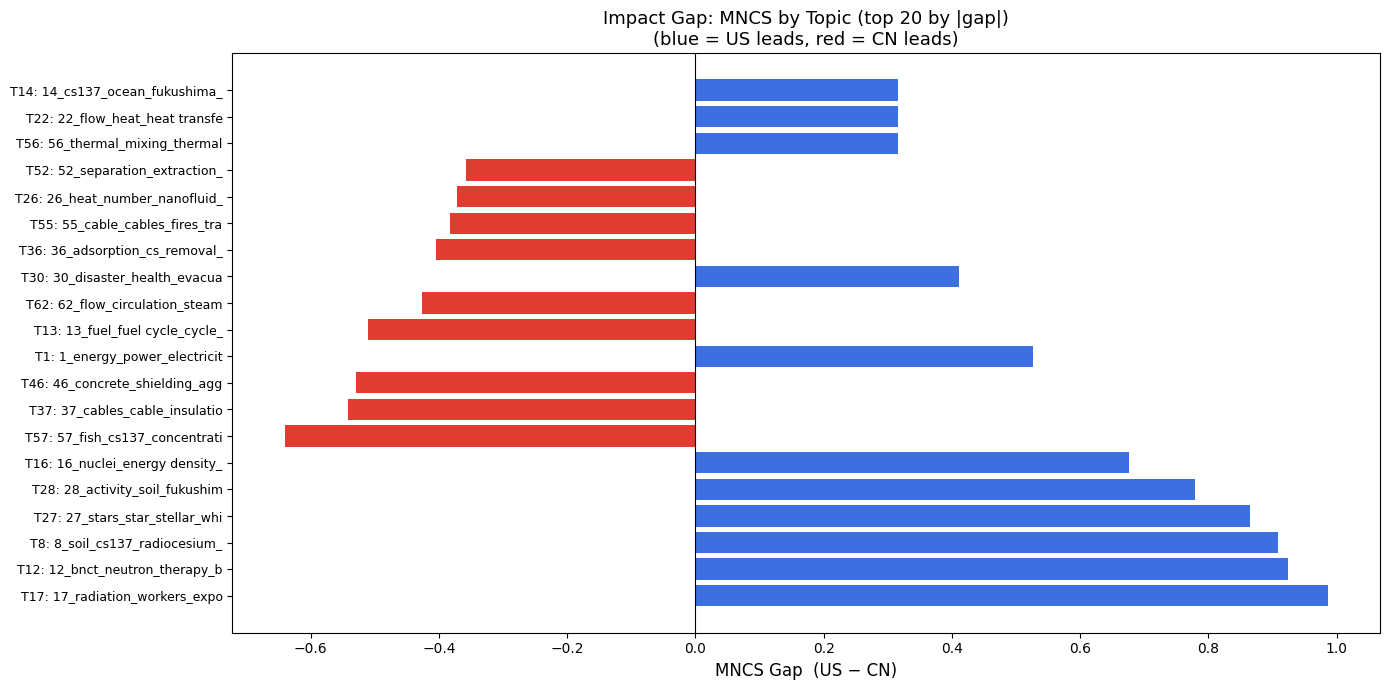

✅ Saved impact_gap_pp10.png


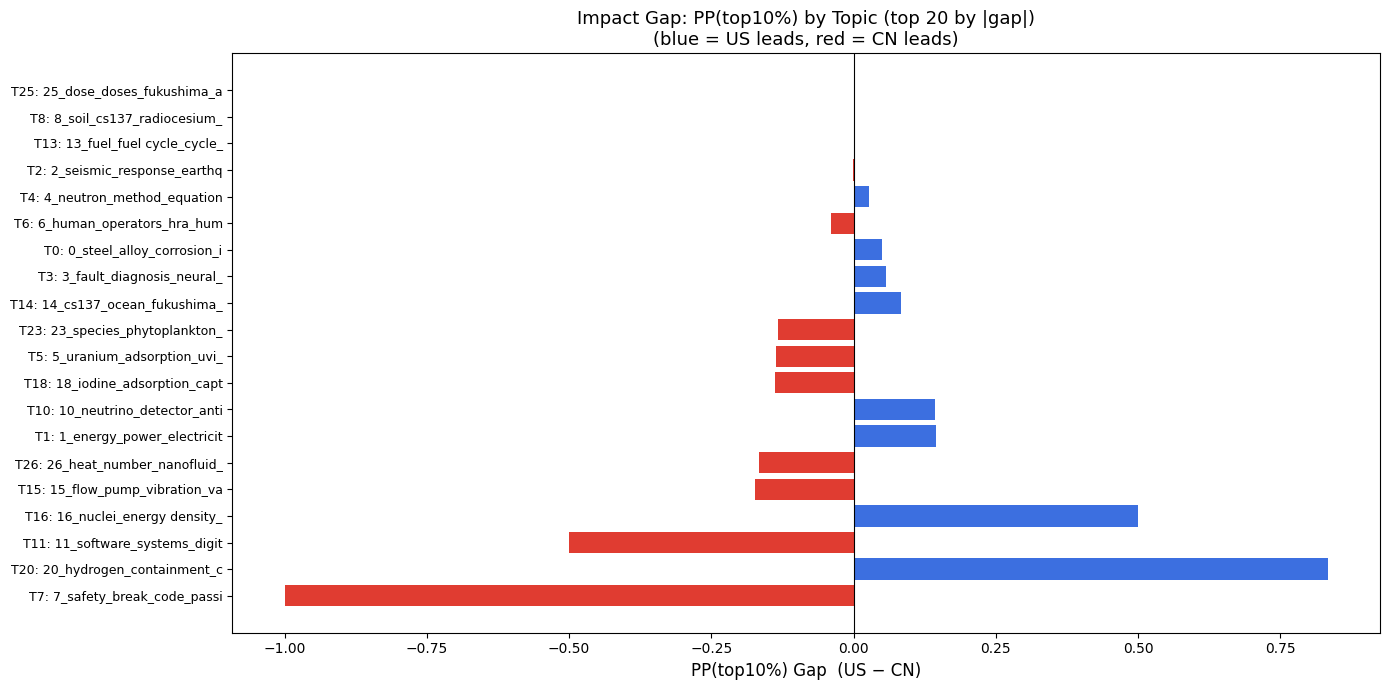

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Impact Gap by Topic (MNCS + PP(top10%))
# ══════════════════════════════════════════════════════════════════════════════

# ── Filter to CN & US papers with valid topic ────────────────────────────────
_cn_us = df_valid[
    df_valid["country2"].isin(["CN", "US"]) & (df_valid[TOPIC_COL] != -1)
].copy()

# ── MNCS by (topic, country) ────────────────────────────────────────────────
mncs_by_ct = (
    _cn_us
    .groupby([TOPIC_COL, "country2"])["nc"]
    .mean()
    .unstack(fill_value=np.nan)
)
mncs_by_ct.columns = [f"MNCS_{c}" for c in mncs_by_ct.columns]
for _col in ["MNCS_CN", "MNCS_US"]:
    if _col not in mncs_by_ct.columns:
        mncs_by_ct[_col] = np.nan
mncs_by_ct["gap_MNCS"] = mncs_by_ct["MNCS_US"] - mncs_by_ct["MNCS_CN"]

# ── PP(top10%) by (topic, country) ──────────────────────────────────────────
pp10_by_ct = (
    _cn_us[_cn_us["q90"].notna()]          # only eligible buckets
    .groupby([TOPIC_COL, "country2"])["top10_flag"]
    .mean()
    .unstack(fill_value=np.nan)
)
pp10_by_ct.columns = [f"PP10_{c}" for c in pp10_by_ct.columns]
for _col in ["PP10_CN", "PP10_US"]:
    if _col not in pp10_by_ct.columns:
        pp10_by_ct[_col] = np.nan
pp10_by_ct["gap_PP10"] = pp10_by_ct["PP10_US"] - pp10_by_ct["PP10_CN"]

# ── Merge & export ───────────────────────────────────────────────────────────
impact_gap = mncs_by_ct.join(pp10_by_ct, how="outer")
impact_gap.index.name = "topic"
impact_gap["topic_name"] = impact_gap.index.map(_name_map)
impact_gap.to_csv(os.path.join(CAP_DIR, "topic_impact_gap.csv"))
print(f"✅ Exported topic_impact_gap.csv  ({len(impact_gap)} topics)")

# ══════════════════════════════════════════════════════════════════════════════
# Chart 1 — MNCS gap (top K topics by |gap|)
# ══════════════════════════════════════════════════════════════════════════════
_p1 = (impact_gap.dropna(subset=["gap_MNCS"])
       .sort_values("gap_MNCS", key=abs, ascending=False)
       .head(TOPK_REPORT))
_labels1 = [f"T{int(t)}: {str(n)[:25]}" for t, n in zip(_p1.index, _p1["topic_name"])]
colors1 = ["#3C6FE0" if g > 0 else "#E03C31" for g in _p1["gap_MNCS"]]

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(_labels1)), _p1["gap_MNCS"].values, color=colors1)
ax.set_yticks(range(len(_labels1)))
ax.set_yticklabels(_labels1, fontsize=9)
ax.set_xlabel("MNCS Gap  (US − CN)", fontsize=12)
ax.set_title(
    f"Impact Gap: MNCS by Topic (top {TOPK_REPORT} by |gap|)\n"
    "(blue = US leads, red = CN leads)", fontsize=13)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
fig.savefig(os.path.join(CAP_DIR, "impact_gap_mncs.png"), dpi=200)
print(f"✅ Saved impact_gap_mncs.png")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Chart 2 — PP(top10%) gap (top K topics by |gap|)
# ══════════════════════════════════════════════════════════════════════════════
_p2 = (impact_gap.dropna(subset=["gap_PP10"])
       .sort_values("gap_PP10", key=abs, ascending=False)
       .head(TOPK_REPORT))
_labels2 = [f"T{int(t)}: {str(n)[:25]}" for t, n in zip(_p2.index, _p2["topic_name"])]
colors2 = ["#3C6FE0" if g > 0 else "#E03C31" for g in _p2["gap_PP10"]]

fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(range(len(_labels2)), _p2["gap_PP10"].values, color=colors2)
ax.set_yticks(range(len(_labels2)))
ax.set_yticklabels(_labels2, fontsize=9)
ax.set_xlabel("PP(top10%) Gap  (US − CN)", fontsize=12)
ax.set_title(
    f"Impact Gap: PP(top10%) by Topic (top {TOPK_REPORT} by |gap|)\n"
    "(blue = US leads, red = CN leads)", fontsize=13)
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
fig.savefig(os.path.join(CAP_DIR, "impact_gap_pp10.png"), dpi=200)
print(f"✅ Saved impact_gap_pp10.png")
plt.show()

## 11.8 Quantity–Quality Quadrant
Scatter plot of every topic $t$ in a four-quadrant space:

- **x-axis (Quantity):** Topic-share gap $P_{CN}(t) - P_{US}(t)$  — positive means CN publishes a larger share
- **y-axis (Quality):** Impact gap $MNCS_{CN}(t) - MNCS_{US}(t)$  — positive means CN has higher normalised impact

Quadrants: upper-right = CN leads both; lower-left = US leads both.

✅ Exported topic_quadrant.csv  (63 topics)
✅ Saved topic_quadrant.png


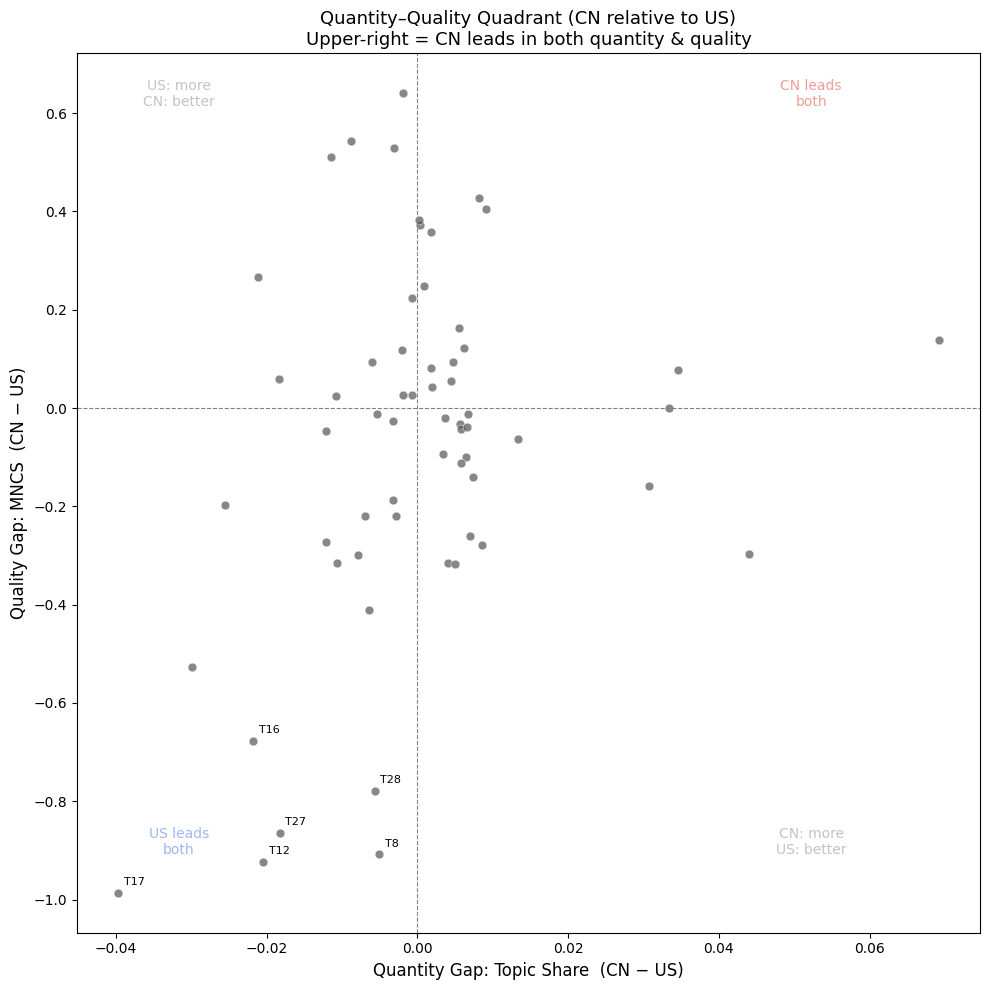

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Quantity–Quality Quadrant
# ══════════════════════════════════════════════════════════════════════════════

# ── Quantity axis: topic share gap (CN − US) using ALL CN/US papers ──────────
_all_cn_us_valid = df_valid[
    df_valid["country2"].isin(["CN", "US"]) & (df_valid[TOPIC_COL] != -1)
]
cn_share = (
    _all_cn_us_valid[_all_cn_us_valid["country2"] == "CN"][TOPIC_COL]
    .value_counts(normalize=True)
)
us_share = (
    _all_cn_us_valid[_all_cn_us_valid["country2"] == "US"][TOPIC_COL]
    .value_counts(normalize=True)
)
_all_t = sorted(_all_cn_us_valid[TOPIC_COL].unique())
cn_share = cn_share.reindex(_all_t, fill_value=0)
us_share = us_share.reindex(_all_t, fill_value=0)
share_gap = cn_share - us_share      # positive → CN has larger share

# ── Quality axis: MNCS gap (CN − US), reversed from Cell H ──────────────────
quality_mncs = -(impact_gap["gap_MNCS"])  # Cell H: gap_MNCS = US − CN → negate
quality_pp10 = -(impact_gap["gap_PP10"])

# ── Build quadrant table ────────────────────────────────────────────────────
quadrant_df = pd.DataFrame({
    "topic": _all_t,
    "share_gap_CN_minus_US": share_gap.values,
    "mncs_gap_CN_minus_US":  quality_mncs.reindex(_all_t).values,
    "pp10_gap_CN_minus_US":  quality_pp10.reindex(_all_t).values,
})
quadrant_df["topic_name"] = quadrant_df["topic"].map(_name_map)
quadrant_df.to_csv(os.path.join(CAP_DIR, "topic_quadrant.csv"), index=False)
print(f"✅ Exported topic_quadrant.csv  ({len(quadrant_df)} topics)")

# ── Scatter: Quantity (x) vs Quality-MNCS (y) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
x = quadrant_df["share_gap_CN_minus_US"].values
y = quadrant_df["mncs_gap_CN_minus_US"].values

ax.scatter(x, y, s=40, alpha=0.7, c="#555555", edgecolors="white", linewidths=0.5)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

# Annotate outliers (top 8 by Euclidean distance from origin)
_d = np.sqrt(x ** 2 + y ** 2)
_idx_out = np.argsort(_d)[-8:]
for _i in _idx_out:
    _row = quadrant_df.iloc[_i]
    ax.annotate(
        f"T{int(_row['topic'])}",
        (x[_i], y[_i]),
        fontsize=8, ha="left", va="bottom",
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_xlabel("Quantity Gap: Topic Share  (CN − US)", fontsize=12)
ax.set_ylabel("Quality Gap: MNCS  (CN − US)", fontsize=12)
ax.set_title(
    "Quantity–Quality Quadrant (CN relative to US)\n"
    "Upper-right = CN leads in both quantity & quality",
    fontsize=13,
)

# Quadrant labels
_xl = ax.get_xlim(); _yl = ax.get_ylim()
ax.text(_xl[1] * 0.70, _yl[1] * 0.85, "CN leads\nboth",
        ha="center", fontsize=10, color="#E03C31", alpha=0.5)
ax.text(_xl[0] * 0.70, _yl[0] * 0.85, "US leads\nboth",
        ha="center", fontsize=10, color="#3C6FE0", alpha=0.5)
ax.text(_xl[1] * 0.70, _yl[0] * 0.85, "CN: more\nUS: better",
        ha="center", fontsize=10, color="#888888", alpha=0.5)
ax.text(_xl[0] * 0.70, _yl[1] * 0.85, "US: more\nCN: better",
        ha="center", fontsize=10, color="#888888", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(CAP_DIR, "topic_quadrant.png"), dpi=200)
print(f"✅ Saved topic_quadrant.png")
plt.show()

## 11.9 Summary Exports
Generate a structured JSON and a human-readable Markdown summary of all capability-gap findings, then list the output directory.

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell J — Summary Exports
# ══════════════════════════════════════════════════════════════════════════════

# ── Gather top findings ──────────────────────────────────────────────────────

# Top frontier distribution deltas
_top_fr_dist = (
    frontier_topic_dist.head(5)[["topic", "topic_name", "delta_F"]]
    .to_dict("records")
)

# Top frontier semantic gaps
_sem_valid = (
    semantic_gap_df[~semantic_gap_df["skipped"]]
    .dropna(subset=["gap_frontier_semantic"])
)
_top_sem_gap = (
    _sem_valid.sort_values("gap_frontier_semantic", ascending=False)
    .head(5)[["topic", "topic_name", "gap_frontier_semantic"]]
    .to_dict("records")
)

# Top MNCS impact gaps (US leads)
_top_mncs = (
    impact_gap.dropna(subset=["gap_MNCS"])
    .sort_values("gap_MNCS", ascending=False).head(5)
)
_top_mncs_list = [
    {"topic": int(t), "topic_name": str(n), "gap_MNCS": round(float(g), 4)}
    for t, n, g in zip(_top_mncs.index, _top_mncs["topic_name"], _top_mncs["gap_MNCS"])
]

# Top PP10 impact gaps (US leads)
_top_pp10 = (
    impact_gap.dropna(subset=["gap_PP10"])
    .sort_values("gap_PP10", ascending=False).head(5)
)
_top_pp10_list = [
    {"topic": int(t), "topic_name": str(n), "gap_PP10": round(float(g), 4)}
    for t, n, g in zip(_top_pp10.index, _top_pp10["topic_name"], _top_pp10["gap_PP10"])
]

# ── Build summary dict ───────────────────────────────────────────────────────
summary = {
    "analysis_date": pd.Timestamp.now().isoformat(),
    "config": {
        "TOPIC_COL": TOPIC_COL,
        "WINDOW_YEARS": WINDOW_YEARS,
        "EXCLUDE_RECENT_YEARS": EXCLUDE_RECENT_YEARS,
        "MIN_BUCKET_SIZE": MIN_BUCKET_SIZE,
        "MIN_FRONTIER_US": MIN_FRONTIER_US,
        "FRONTIER_TYPE": FRONTIER_COL,
        "frontier_window": f"{frontier_year_start}-{frontier_year_end}",
    },
    "frontier_distribution": {
        "js_distance": round(float(js_dist_frontier), 6),
        "jsd": round(float(jsd_frontier), 6),
        "top_delta_topics": _top_fr_dist,
    },
    "frontier_semantic_gap": {
        "topics_computed": int((~semantic_gap_df["skipped"]).sum()),
        "topics_skipped": int(semantic_gap_df["skipped"].sum()),
        "top_gap_topics_CN_farther": _top_sem_gap,
    },
    "impact_gap": {
        "top_mncs_gap_US_leads": _top_mncs_list,
        "top_pp10_gap_US_leads": _top_pp10_list,
    },
}

# ── Write JSON ───────────────────────────────────────────────────────────────
with open(os.path.join(CAP_DIR, "capability_gap_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)
print("✅ Exported capability_gap_summary.json")

# ── Write Markdown ───────────────────────────────────────────────────────────
md = [
    "# Capability Gap Summary\n",
    f"**Analysis date:** {summary['analysis_date']}\n",
    "## Configuration",
    f"- Topic column: `{TOPIC_COL}`",
    f"- Frontier type: `{FRONTIER_COL}` (window {frontier_year_start}–{frontier_year_end})",
    f"- Exclude recent years: {EXCLUDE_RECENT_YEARS}",
    f"- Min bucket size: {MIN_BUCKET_SIZE}; Min US frontier/topic: {MIN_FRONTIER_US}\n",
    "## 1. Frontier Distribution Gap",
    f"- JS distance: **{js_dist_frontier:.4f}**   JSD: **{jsd_frontier:.4f}**",
    "- Top topics where US frontier share exceeds CN frontier (largest |Δ|):",
]
for r in _top_fr_dist:
    md.append(f"  - T{r['topic']} ({str(r.get('topic_name',''))[:40]}): "
              f"Δ = {r['delta_F']:.4f}")

md += [
    "\n## 2. Frontier Semantic Gap (centre-based)",
    f"- Topics computed: {summary['frontier_semantic_gap']['topics_computed']}",
    f"- Topics skipped (insufficient US frontier): "
    f"{summary['frontier_semantic_gap']['topics_skipped']}",
    "- Top topics where CN is farthest from US frontier:",
]
for r in _top_sem_gap:
    md.append(f"  - T{r['topic']} ({str(r.get('topic_name',''))[:40]}): "
              f"gap = {r['gap_frontier_semantic']:.4f}")

md += ["\n## 3. Impact Gap — MNCS", "- Top topics where US leads:"]
for r in _top_mncs_list:
    md.append(f"  - T{r['topic']} ({str(r.get('topic_name',''))[:40]}): "
              f"gap = {r['gap_MNCS']:.4f}")

md += ["\n## 4. Impact Gap — PP(top 10 %)", "- Top topics where US leads:"]
for r in _top_pp10_list:
    md.append(f"  - T{r['topic']} ({str(r.get('topic_name',''))[:40]}): "
              f"gap = {r['gap_PP10']:.4f}")

with open(os.path.join(CAP_DIR, "capability_gap_summary.md"), "w") as f:
    f.write("\n".join(md))
print("✅ Exported capability_gap_summary.md")

# ── Print output listing ─────────────────────────────────────────────────────
print(f"\n{'═' * 60}")
print(f"  Capability-gap outputs: {os.path.abspath(CAP_DIR)}")
print(f"{'═' * 60}")
for root, dirs, files in os.walk(CAP_DIR):
    level = root.replace(CAP_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = "  " * (level + 1)
    for fn in sorted(files):
        fpath = os.path.join(root, fn)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"{sub_indent}{fn}  ({size_mb:.2f} MB)")

print(f"\n🎉 Capability-gap analysis complete!")

✅ Exported capability_gap_summary.json
✅ Exported capability_gap_summary.md

════════════════════════════════════════════════════════════
  Capability-gap outputs: /Users/luoyiti/Project/catch-up/output/cluster_results/capability_gap
════════════════════════════════════════════════════════════
capability_gap/
  capability_gap_summary.json  (0.00 MB)
  capability_gap_summary.md  (0.00 MB)
  frontier_js_metrics.json  (0.00 MB)
  frontier_papers.csv  (0.05 MB)
  frontier_semantic_gap_by_topic.csv  (0.00 MB)
  frontier_semantic_gap_by_topic.png  (0.05 MB)
  frontier_topic_distribution.csv  (0.00 MB)
  frontier_topic_distribution.png  (0.22 MB)
  impact_gap_mncs.png  (0.16 MB)
  impact_gap_pp10.png  (0.16 MB)
  paper_norm_citations.csv  (0.99 MB)
  paper_top10_flag.csv  (0.91 MB)
  topic_impact_gap.csv  (0.01 MB)
  topic_quadrant.csv  (0.01 MB)
  topic_quadrant.png  (0.13 MB)

🎉 Capability-gap analysis complete!


# 12. Topics over Time — Time-Evolution Evidence Chain
Compute per-topic share time-series for CN and US (yearly & 5-year rolling window), classify catching-up / pulling-away trends, and visualise the dynamics.

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.1  Data Cleaning & Standardisation for Time-Evolution Analysis
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
import warnings

# ── Output sub-directory ─────────────────────────────────────────────────────
TIME_DIR = Path(OUTPUT_DIR) / "time_evolution"
FIGS_DIR = TIME_DIR / "figs"
TIME_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Select base DataFrame ───────────────────────────────────────────────────
base_df = df_valid.copy() if "df_valid" in dir() and df_valid is not None else df.copy()
print(f"Base DataFrame rows: {len(base_df):,}")

# ── Detect topic column (reuse TOPIC_COL from §11 or auto-detect) ───────────
_tc_candidates = ["topic_reduced", "topic_reassign", "topic"]
topic_col = None
if "TOPIC_COL" in dir() and TOPIC_COL in base_df.columns:
    topic_col = TOPIC_COL
else:
    for _c in _tc_candidates:
        if _c in base_df.columns and base_df[_c].notna().any():
            topic_col = _c
            break
if topic_col is None:
    raise RuntimeError("No topic column found – run BERTopic first.")
print(f"topic_col = '{topic_col}'")

# ── Ensure 'country2' exists ────────────────────────────────────────────────
if "country2" not in base_df.columns:
    if "country_code" in base_df.columns:
        base_df["country2"] = base_df["country_code"].map(
            lambda c: "CN" if c == "CN" else ("US" if c == "US" else "OTHER")
        )
    else:
        raise RuntimeError("No country column found.")

# ── Filter CN & US, exclude noise topic ──────────────────────────────────────
te_df = base_df[base_df["country2"].isin(["CN", "US"])].copy()
te_df = te_df[te_df[topic_col].notna()].copy()
te_df[topic_col] = te_df[topic_col].astype(int)
te_df = te_df[te_df[topic_col] != -1].copy()

# ── Year cleaning ────────────────────────────────────────────────────────────
YEAR_COL_TE = "year"   # may differ from YEAR_COL in §11
if YEAR_COL_TE not in te_df.columns:
    for _yc in ["year", "Year", "pub_year", "PY"]:
        if _yc in te_df.columns:
            YEAR_COL_TE = _yc
            break
te_df["year_int"] = pd.to_numeric(te_df[YEAR_COL_TE], errors="coerce")
te_df = te_df.dropna(subset=["year_int"]).copy()
te_df["year_int"] = te_df["year_int"].astype(int)

# Auto min/max
min_year = int(te_df["year_int"].min())
max_year_te = int(te_df["year_int"].max())
# Sanity guard
min_year = max(min_year, 1900)
max_year_te = min(max_year_te, 2100)
te_df = te_df[(te_df["year_int"] >= min_year) & (te_df["year_int"] <= max_year_te)].copy()

print(f"✅ Time-evolution base data: {len(te_df):,} papers")
print(f"   Year range: {min_year} – {max_year_te}")
print(f"   Topics: {te_df[topic_col].nunique()}")
print(f"   CN: {(te_df['country2']=='CN').sum():,}  US: {(te_df['country2']=='US').sum():,}")

Base DataFrame rows: 14,299
topic_col = 'topic'
✅ Time-evolution base data: 5,315 papers
   Year range: 1990 – 2026
   Topics: 63
   CN: 3,465  US: 1,850


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.2  Build yearly topic share
# ══════════════════════════════════════════════════════════════════════════════

def build_topic_time_series(df_in, topic_col, year_col="year_int",
                            country_col="country2"):
    """
    Compute yearly topic share for CN and US.

    Returns
    -------
    yearly : pd.DataFrame with columns
        [topic, year, count_CN, count_US, share_CN, share_US, delta]
    """
    counts = (
        df_in.groupby([topic_col, year_col, country_col])
        .size()
        .reset_index(name="n")
    )

    # Total papers per country-year (denominator for share)
    country_year_total = (
        df_in.groupby([year_col, country_col])
        .size()
        .reset_index(name="n_total")
    )
    counts = counts.merge(country_year_total, on=[year_col, country_col], how="left")
    counts["share"] = counts["n"] / counts["n_total"]

    # Pivot to wide: one row per (topic, year)
    wide_count = counts.pivot_table(
        index=[topic_col, year_col], columns=country_col, values="n", fill_value=0
    ).reset_index()
    wide_share = counts.pivot_table(
        index=[topic_col, year_col], columns=country_col, values="share", fill_value=0
    ).reset_index()

    for c in ["CN", "US"]:
        if c not in wide_count.columns:
            wide_count[c] = 0
        if c not in wide_share.columns:
            wide_share[c] = 0.0

    result = pd.DataFrame({
        "topic":    wide_count[topic_col],
        "year":     wide_count[year_col],
        "count_CN": wide_count["CN"],
        "count_US": wide_count["US"],
        "share_CN": wide_share["CN"],
        "share_US": wide_share["US"],
    })
    result["delta"] = result["share_CN"] - result["share_US"]
    return result.sort_values(["topic", "year"]).reset_index(drop=True)

yearly = build_topic_time_series(te_df, topic_col)
yearly.to_csv(TIME_DIR / "topic_share_yearly.csv", index=False)
print(f"✅ Exported topic_share_yearly.csv  ({len(yearly):,} rows)")
yearly.head(10)

✅ Exported topic_share_yearly.csv  (1,103 rows)


,topic,year,count_CN,count_US,share_CN,share_US,delta
0,0,1990,0.0,1.0,0.0,0.142857,-0.142857
1,0,1991,0.0,5.0,0.0,0.151515,-0.151515
2,0,1992,1.0,3.0,0.5,0.090909,0.409091
3,0,1993,2.0,3.0,0.5,0.083333,0.416667
4,0,1994,0.0,6.0,0.0,0.166667,-0.166667
5,0,1995,1.0,5.0,0.5,0.156250,0.343750
6,0,1996,1.0,7.0,0.5,0.152174,0.347826
7,0,1997,0.0,7.0,0.0,0.212121,-0.212121
8,0,1998,2.0,3.0,0.5,0.088235,0.411765
9,0,1999,0.0,3.0,0.0,0.142857,-0.142857


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.3  Build 5-year rolling-window topic share
# ══════════════════════════════════════════════════════════════════════════════

def build_rolling_share(df_in, topic_col, year_col="year_int",
                        country_col="country2", window=5, min_periods=3):
    """
    Compute 5-year rolling-window topic share for CN and US.

    Steps:
      1. Pivot counts to wide: index=[topic, year], columns=country, values=count
      2. Per topic-country: rolling(window).sum()
      3. Re-normalise within each year-country (denominator = sum of rolling counts)

    Returns
    -------
    roll_df : pd.DataFrame with columns
        [topic, year, roll_count_CN, roll_count_US, share_CN, share_US, delta]
    """
    counts = (
        df_in.groupby([topic_col, year_col, country_col])
        .size()
        .reset_index(name="n")
    )
    wide = counts.pivot_table(
        index=[topic_col, year_col], columns=country_col, values="n", fill_value=0
    ).reset_index()
    for c in ["CN", "US"]:
        if c not in wide.columns:
            wide[c] = 0

    all_years = sorted(df_in[year_col].unique())
    all_topics = sorted(df_in[topic_col].unique())

    # Full index so rolling works continuously
    full_idx = pd.MultiIndex.from_product(
        [all_topics, all_years], names=[topic_col, year_col]
    )
    wide = wide.set_index([topic_col, year_col]).reindex(full_idx, fill_value=0).reset_index()

    # Rolling sum per topic-country
    wide = wide.sort_values([topic_col, year_col])
    for c in ["CN", "US"]:
        wide[f"roll_{c}"] = (
            wide.groupby(topic_col)[c]
            .transform(lambda s: s.rolling(window=window, min_periods=min_periods).sum())
        )

    # Drop rows where rolling is NaN (not enough history)
    wide = wide.dropna(subset=["roll_CN", "roll_US"]).copy()

    # Denominator: total rolling counts per country-year
    for c in ["CN", "US"]:
        year_total = wide.groupby(year_col)[f"roll_{c}"].transform("sum")
        wide[f"share_{c}"] = wide[f"roll_{c}"] / year_total.replace(0, np.nan)
    wide["share_CN"] = wide["share_CN"].fillna(0)
    wide["share_US"] = wide["share_US"].fillna(0)
    wide["delta"] = wide["share_CN"] - wide["share_US"]

    result = wide[[topic_col, year_col, "roll_CN", "roll_US",
                    "share_CN", "share_US", "delta"]].copy()
    result.columns = ["topic", "year", "roll_count_CN", "roll_count_US",
                       "share_CN", "share_US", "delta"]
    return result.sort_values(["topic", "year"]).reset_index(drop=True)

roll5 = build_rolling_share(te_df, topic_col, window=5, min_periods=3)
roll5.to_csv(TIME_DIR / "topic_share_roll5.csv", index=False)
print(f"✅ Exported topic_share_roll5.csv  ({len(roll5):,} rows)")
roll5.head(10)

✅ Exported topic_share_roll5.csv  (2,205 rows)


,topic,year,roll_count_CN,roll_count_US,share_CN,share_US,delta
0,0,1992,1.0,9.0,0.500000,0.123288,0.376712
1,0,1993,3.0,12.0,0.500000,0.110092,0.389908
2,0,1994,3.0,18.0,0.375000,0.124138,0.250862
3,0,1995,4.0,22.0,0.400000,0.129412,0.270588
4,0,1996,5.0,24.0,0.416667,0.131148,0.285519
5,0,1997,4.0,28.0,0.400000,0.153005,0.246995
6,0,1998,4.0,28.0,0.400000,0.154696,0.245304
7,0,1999,4.0,25.0,0.333333,0.150602,0.182731
8,0,2000,4.0,21.0,0.307692,0.135484,0.172208
9,0,2001,3.0,18.0,0.214286,0.135338,0.078947


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.4  Classify trends: catching-up / pulling-away / stable
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.linear_model import TheilSenRegressor

def classify_trends(roll_df, min_years=6, eps=1e-4):
    """
    For each topic, fit a robust slope on delta(t) from the roll5 series.

    Returns
    -------
    summary : pd.DataFrame with columns
        [topic, slope_delta, delta_start, delta_end, cross_year, trend_label, n_years]
    """
    records = []
    for t, grp in roll_df.groupby("topic"):
        grp = grp.sort_values("year").dropna(subset=["delta"])
        n = len(grp)
        if n < min_years:
            records.append({
                "topic": int(t), "slope_delta": np.nan,
                "delta_start": np.nan, "delta_end": np.nan,
                "cross_year": np.nan, "trend_label": "insufficient",
                "n_years": n
            })
            continue

        years = grp["year"].values.reshape(-1, 1).astype(float)
        deltas = grp["delta"].values.astype(float)

        # Robust slope via Theil-Sen
        try:
            ts = TheilSenRegressor(random_state=SEED, max_subpopulation=5000)
            ts.fit(years, deltas)
            slope = float(ts.coef_[0])
        except Exception:
            # Fallback to simple polyfit
            slope = float(np.polyfit(years.ravel(), deltas, 1)[0])

        delta_start = float(deltas[0])
        delta_end   = float(deltas[-1])

        # Crossing: delta goes from <0 to >=0 (CN overtakes US in share)
        cross_year = np.nan
        for i in range(1, len(deltas)):
            if deltas[i - 1] < 0 and deltas[i] >= 0:
                cross_year = int(grp["year"].values[i])
                break

        # Label
        if slope > eps and (delta_end > delta_start + eps):
            label = "catching_up"
        elif slope < -eps:
            label = "pulling_away"
        else:
            label = "stable"

        records.append({
            "topic": int(t), "slope_delta": round(slope, 8),
            "delta_start": round(delta_start, 6),
            "delta_end": round(delta_end, 6),
            "cross_year": cross_year,
            "trend_label": label,
            "n_years": n,
        })
    return pd.DataFrame(records)

trend_summary = classify_trends(roll5, min_years=6, eps=1e-4)
trend_summary.to_csv(TIME_DIR / "topic_trend_summary.csv", index=False)
print(f"✅ Exported topic_trend_summary.csv  ({len(trend_summary)} topics)")
print(f"\nTrend distribution:")
print(trend_summary["trend_label"].value_counts().to_string())
trend_summary.sort_values("slope_delta", ascending=False).head(10)

✅ Exported topic_trend_summary.csv  (63 topics)

Trend distribution:
trend_label
catching_up     32
stable          19
pulling_away    12


,topic,slope_delta,delta_start,delta_end,cross_year,trend_label,n_years
3,3,0.004153,-0.068493,0.021668,2015.0,catching_up,35
9,9,0.003323,-0.109589,-0.005900,2008.0,catching_up,35
6,6,0.001669,-0.095890,-0.009208,2002.0,catching_up,35
2,2,0.001495,-0.027397,-0.008847,2013.0,catching_up,35
15,15,0.001423,-0.013699,0.032976,1998.0,catching_up,35
5,5,0.001329,0.000000,0.096106,1999.0,catching_up,35
7,7,0.001316,0.000000,0.003603,2003.0,catching_up,35
1,1,0.001276,-0.123288,-0.032414,1993.0,catching_up,35
12,12,0.001275,-0.027397,-0.006471,NaN,catching_up,35
23,23,0.001234,-0.027397,0.016708,2000.0,catching_up,35


Visualising 20 topics (by |slope_delta|): [0, 3, 4, 9, 6, 2, 15, 5, 7, 1, 12, 23, 25, 10, 45, 31, 37, 32, 41, 8]
✅ Saved 40 per-topic plots to output/cluster_results/time_evolution/figs
✅ Saved delta_overview_topk.png


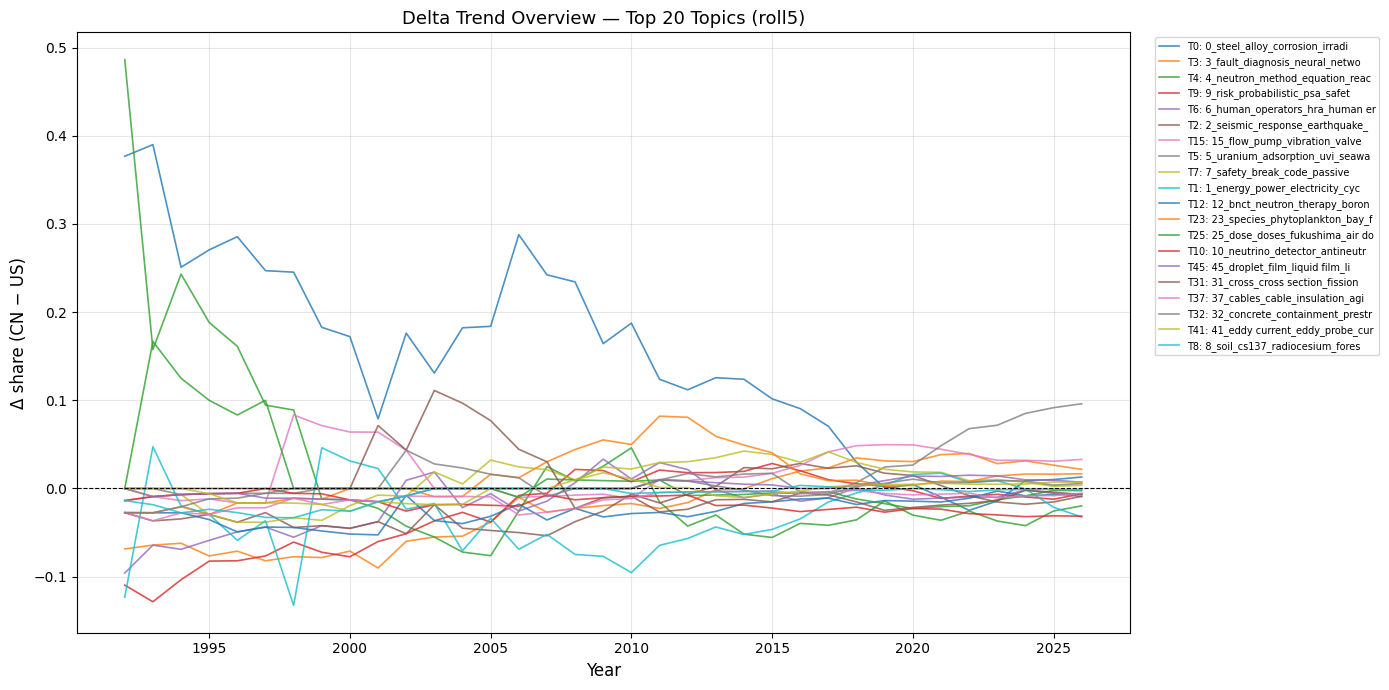

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# 12.5  Visualisation — TopK topic share & delta curves
# ══════════════════════════════════════════════════════════════════════════════
TOPK_VIS = TOPK_REPORT if "TOPK_REPORT" in dir() else 20

# ── Helper: topic name map (reuse from §11 if available) ─────────────────────
_name_map_te = {}
if "topic_info_export" in dir():
    _name_map_te = dict(zip(topic_info_export["topic_id"], topic_info_export["name"]))
elif "_name_map" in dir():
    _name_map_te = _name_map

def _topic_label(tid):
    name = str(_name_map_te.get(tid, ""))[:30]
    return f"T{tid}: {name}" if name else f"T{tid}"

# ── Select TopK by |slope_delta| among classified topics ─────────────────────
_ranked = (
    trend_summary[trend_summary["trend_label"] != "insufficient"]
    .sort_values("slope_delta", key=abs, ascending=False)
    .head(TOPK_VIS)
)
topk_topics = _ranked["topic"].tolist()
print(f"Visualising {len(topk_topics)} topics (by |slope_delta|): {topk_topics}")


def plot_share_over_time(roll_df, tid, out_dir):
    """Plot CN vs US share (roll5) for a single topic."""
    sub = roll_df[roll_df["topic"] == tid].sort_values("year")
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sub["year"], sub["share_CN"], "o-", color="#E03C31", label="CN share", markersize=3)
    ax.plot(sub["year"], sub["share_US"], "s-", color="#3C6FE0", label="US share", markersize=3)
    ax.set_xlabel("Year")
    ax.set_ylabel("Topic share (roll5)")
    ax.set_title(f"Share over Time — {_topic_label(tid)}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_dir / f"share_T{tid}.png", dpi=150)
    plt.close(fig)


def plot_delta_over_time(roll_df, tid, trend_row, out_dir):
    """Plot delta(t) = share_CN - share_US for a single topic."""
    sub = roll_df[roll_df["topic"] == tid].sort_values("year")
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sub["year"], sub["delta"], "o-", color="#6A0DAD", markersize=3)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.fill_between(sub["year"], sub["delta"], 0, alpha=0.15, color="#6A0DAD")

    # Mark cross_year if present
    cross = trend_row.get("cross_year", np.nan)
    if pd.notna(cross):
        ax.axvline(cross, color="green", linewidth=1.5, linestyle=":", label=f"cross year={int(cross)}")
        ax.legend(fontsize=9)

    label = trend_row.get("trend_label", "")
    slope = trend_row.get("slope_delta", np.nan)
    slope_str = f"{slope:.2e}" if pd.notna(slope) else "N/A"
    ax.set_xlabel("Year")
    ax.set_ylabel("Δ share (CN − US)")
    ax.set_title(f"Delta over Time — {_topic_label(tid)}  [{label}, slope={slope_str}]")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_dir / f"delta_T{tid}.png", dpi=150)
    plt.close(fig)


# ── Generate per-topic plots ─────────────────────────────────────────────────
trend_dict = trend_summary.set_index("topic").to_dict("index")
for tid in topk_topics:
    plot_share_over_time(roll5, tid, FIGS_DIR)
    tr = trend_dict.get(tid, {})
    plot_delta_over_time(roll5, tid, tr, FIGS_DIR)

print(f"✅ Saved {len(topk_topics)*2} per-topic plots to {FIGS_DIR}")


# ── Overview: TopK delta curves overlay ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for tid in topk_topics:
    sub = roll5[roll5["topic"] == tid].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], sub["delta"], "-", linewidth=1.2,
            label=_topic_label(tid), alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Δ share (CN − US)", fontsize=12)
ax.set_title(f"Delta Trend Overview — Top {len(topk_topics)} Topics (roll5)", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGS_DIR / "delta_overview_topk.png", dpi=200, bbox_inches="tight")
print(f"✅ Saved delta_overview_topk.png")
plt.show()

# 13. Lead–Lag Analysis (Entry Period & Lag Years)
For each topic, determine when CN and US "entered" the field (sustained growth above baseline) and compute the lag in years. Validate with cross-correlation.

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.1  Detect enter_year for each topic-country
# ══════════════════════════════════════════════════════════════════════════════

def detect_enter_year(series_year, series_share, k=1.0, L=2, min_baseline=3):
    """
    Detect the 'entry year' for a topic-country share time-series.

    Parameters
    ----------
    series_year : array-like of int — sorted years
    series_share : array-like of float — corresponding share values
    k : float — number of sigma above baseline mean
    L : int — look-ahead window for sustained growth check
    min_baseline : int — minimum baseline years

    Returns
    -------
    enter_year : int or NaN
    flag : str — 'ok' or 'insufficient' or 'not_found'
    """
    years = np.array(series_year)
    shares = np.array(series_share, dtype=float)
    n = len(years)

    if n < min_baseline + L:
        return np.nan, "insufficient"

    # Baseline: first B years
    B = min(5, max(min_baseline, n // 3))
    mu = shares[:B].mean()
    sigma = shares[:B].std()
    if sigma == 0 or np.isnan(sigma):
        sigma = 1e-8

    threshold = mu + k * sigma

    for i in range(B, n):
        if shares[i] > threshold:
            # Check sustained growth: average change over next L years >= 0
            end_check = min(i + L, n - 1)
            if end_check > i:
                future_diffs = np.diff(shares[i:end_check + 1])
                if future_diffs.mean() >= 0:
                    return int(years[i]), "ok"
            else:
                # At the edge of data — accept if above threshold
                return int(years[i]), "ok"

    return np.nan, "not_found"


# ── Build per-topic-country share series from roll5 ──────────────────────────
lead_lag_records = []

for t in sorted(roll5["topic"].unique()):
    sub = roll5[roll5["topic"] == t].sort_values("year")
    if sub.empty:
        continue

    result = {"topic": int(t)}
    for country in ["CN", "US"]:
        col = f"share_{country}"
        valid = sub.dropna(subset=[col])
        if len(valid) < 5:
            result[f"enter_{country}"] = np.nan
            result[f"flag_{country}"] = "insufficient"
        else:
            ey, flag = detect_enter_year(valid["year"].values, valid[col].values)
            result[f"enter_{country}"] = ey
            result[f"flag_{country}"] = flag

    lead_lag_records.append(result)

lead_lag_df = pd.DataFrame(lead_lag_records)
print(f"✅ Entry-year detection done for {len(lead_lag_df)} topics")
print(f"   CN enter found: {lead_lag_df['enter_CN'].notna().sum()}")
print(f"   US enter found: {lead_lag_df['enter_US'].notna().sum()}")

✅ Entry-year detection done for 63 topics
   CN enter found: 54
   US enter found: 49


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.2  Compute lag + 13.3 Cross-correlation validation
# ══════════════════════════════════════════════════════════════════════════════

def compute_lead_lag(lead_lag_df):
    """Compute lag = enter_CN - enter_US and assign label."""
    df_ll = lead_lag_df.copy()
    both_valid = df_ll["enter_CN"].notna() & df_ll["enter_US"].notna()
    df_ll["lag"] = np.nan
    df_ll.loc[both_valid, "lag"] = (
        df_ll.loc[both_valid, "enter_CN"] - df_ll.loc[both_valid, "enter_US"]
    )

    def _label(row):
        if pd.isna(row["lag"]):
            return "NA"
        if row["lag"] > 0:
            return "CN_lagging"
        elif row["lag"] < 0:
            return "CN_leading"
        else:
            return "tie"
    df_ll["lag_label"] = df_ll.apply(_label, axis=1)
    return df_ll

lead_lag_df = compute_lead_lag(lead_lag_df)

# ── 13.3 Cross-correlation validation (no extra packages) ───────────────────
def cross_corr_lag(roll_df, topic, max_lag=10):
    """
    Compute cross-correlation between CN and US share series.

    Returns (best_lag, max_corr) or (NaN, NaN) if insufficient data.
    Positive lag means CN lags behind US by that many years.
    """
    sub = roll_df[roll_df["topic"] == topic].sort_values("year")
    cn = sub["share_CN"].values
    us = sub["share_US"].values
    if len(cn) < 6 or np.std(cn) < 1e-10 or np.std(us) < 1e-10:
        return np.nan, np.nan

    best_lag = 0
    best_corr = -2  # below any valid correlation

    for lag in range(-max_lag, max_lag + 1):
        if lag >= 0:
            cn_seg = cn[lag:]
            us_seg = us[:len(cn_seg)]
        else:
            us_seg = us[-lag:]
            cn_seg = cn[:len(us_seg)]
        min_len = min(len(cn_seg), len(us_seg))
        if min_len < 4:
            continue
        cn_seg = cn_seg[:min_len]
        us_seg = us_seg[:min_len]

        # Pearson correlation
        cn_demeaned = cn_seg - cn_seg.mean()
        us_demeaned = us_seg - us_seg.mean()
        denom = np.sqrt((cn_demeaned ** 2).sum() * (us_demeaned ** 2).sum())
        if denom < 1e-15:
            continue
        corr = (cn_demeaned * us_demeaned).sum() / denom
        if corr > best_corr:
            best_corr = corr
            best_lag = lag

    return best_lag, round(float(best_corr), 4) if best_corr > -2 else np.nan

# Apply cross-correlation
ccf_results = []
for t in lead_lag_df["topic"]:
    lag_ccf, max_corr = cross_corr_lag(roll5, t, max_lag=10)
    ccf_results.append({"topic": int(t), "lag_ccf": lag_ccf, "max_corr": max_corr})

ccf_df = pd.DataFrame(ccf_results)
lead_lag_df = lead_lag_df.merge(ccf_df, on="topic", how="left")

# ── Add topic names ──────────────────────────────────────────────────────────
lead_lag_df["topic_name"] = lead_lag_df["topic"].map(_name_map_te)

# ── Export ────────────────────────────────────────────────────────────────────
lead_lag_df.to_csv(TIME_DIR / "topic_lead_lag.csv", index=False)
print(f"✅ Exported topic_lead_lag.csv  ({len(lead_lag_df)} topics)")
print(f"\nLag label distribution:")
print(lead_lag_df["lag_label"].value_counts().to_string())
print(f"\nCross-correlation computed: {lead_lag_df['lag_ccf'].notna().sum()} topics")
lead_lag_df.sort_values("lag", ascending=False).head(10)

✅ Exported topic_lead_lag.csv  (63 topics)

Lag label distribution:
lag_label
CN_lagging    31
NA            22
CN_leading    10

Cross-correlation computed: 61 topics


,topic,enter_CN,flag_CN,enter_US,flag_US,lag,lag_label,lag_ccf,max_corr,topic_name
17,17,2025.0,ok,1997.0,ok,28.0,CN_lagging,0.0,0.3733,17_radiation_workers_exposure_cancer
56,57,2025.0,ok,2000.0,ok,25.0,CN_lagging,7.0,0.3229,57_fish_cs137_concentrations_radiocesium
30,30,2021.0,ok,1997.0,ok,24.0,CN_lagging,2.0,0.4444,30_disaster_health_evacuation_fukushima
12,12,2019.0,ok,1997.0,ok,22.0,CN_lagging,1.0,0.6222,12_bnct_neutron_therapy_boron
45,45,2018.0,ok,1997.0,ok,21.0,CN_lagging,-10.0,0.3652,45_droplet_film_liquid film_liquid
58,59,2018.0,ok,1997.0,ok,21.0,CN_lagging,-5.0,0.8269,59_libs_breakdown spectroscopy_breakdown_laser...
24,24,2018.0,ok,1997.0,ok,21.0,CN_lagging,5.0,0.5954,24_radiation_camera_detector_imaging
51,52,2015.0,ok,1997.0,ok,18.0,CN_lagging,-10.0,0.8250,52_separation_extraction_ligands_complexes
11,11,2013.0,ok,1997.0,ok,16.0,CN_lagging,-7.0,0.5095,11_software_systems_digital_reliability
54,55,2018.0,ok,2003.0,ok,15.0,CN_lagging,10.0,0.5953,55_cable_cables_fires_tray


✅ Saved lead_lag_bar.png


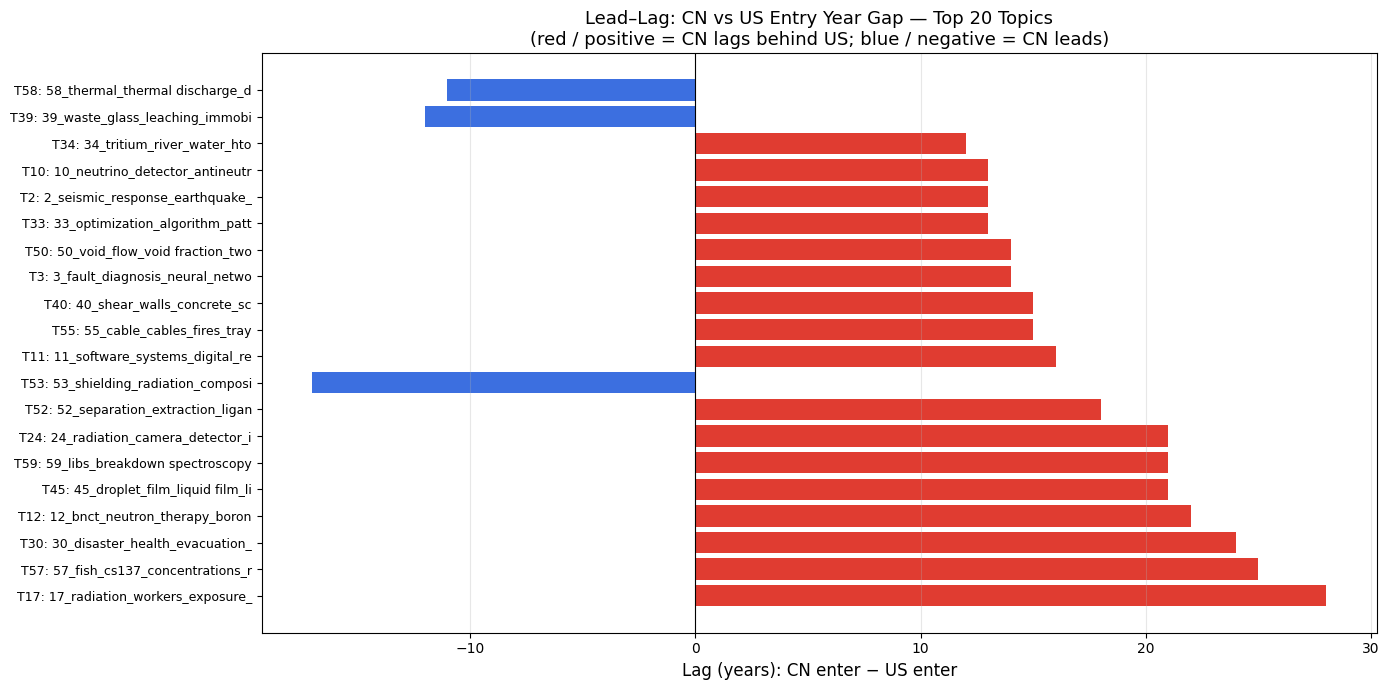

✅ Saved lead_lag_ccf_bar.png


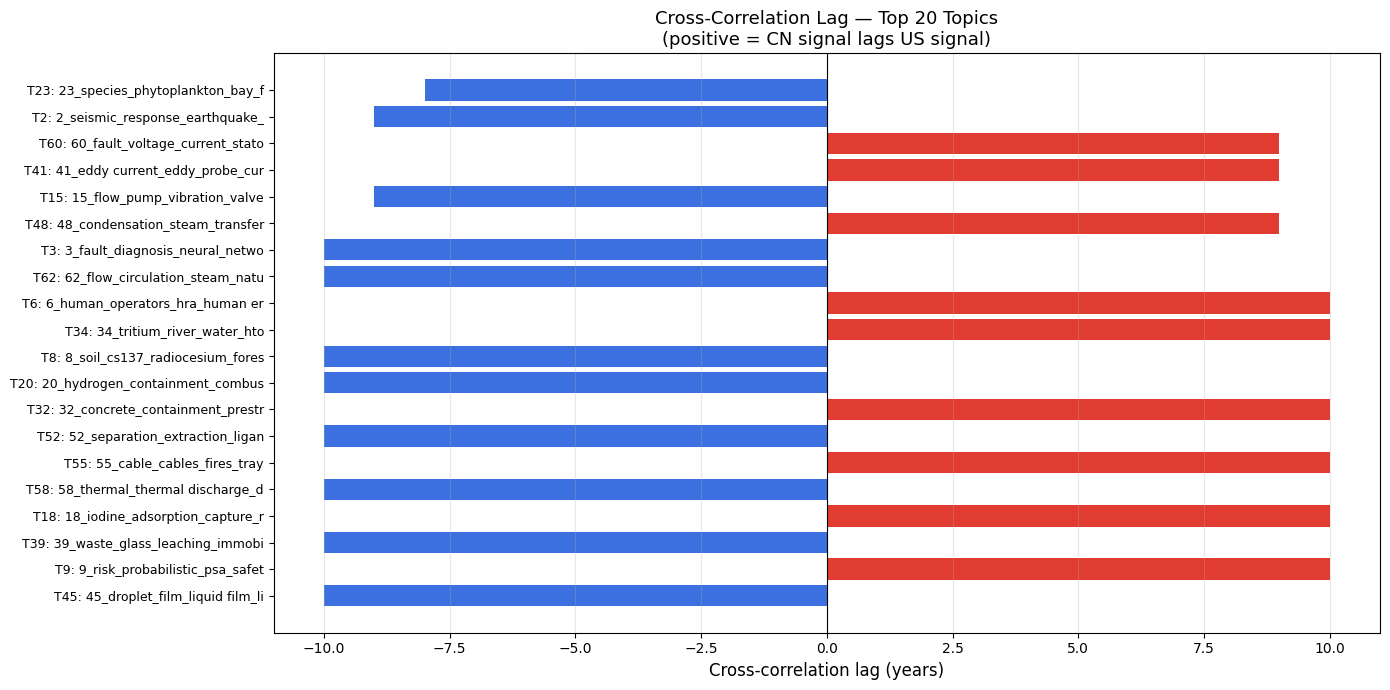

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# 13.4  Visualisation — Lead-lag bar chart
# ══════════════════════════════════════════════════════════════════════════════

# ── Bar chart: lag by topic (sorted, TopK by |lag|) ──────────────────────────
_valid_lag = lead_lag_df.dropna(subset=["lag"]).copy()
_valid_lag["abs_lag"] = _valid_lag["lag"].abs()
_plot_lag = _valid_lag.sort_values("abs_lag", ascending=False).head(TOPK_VIS)

if len(_plot_lag) > 0:
    _labels = [_topic_label(int(t)) for t in _plot_lag["topic"]]
    _lags = _plot_lag["lag"].values
    colors = ["#E03C31" if lg > 0 else ("#3C6FE0" if lg < 0 else "#888888")
              for lg in _lags]

    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(range(len(_labels)), _lags, color=colors)
    ax.set_yticks(range(len(_labels)))
    ax.set_yticklabels(_labels, fontsize=9)
    ax.set_xlabel("Lag (years): CN enter − US enter", fontsize=12)
    ax.set_title(
        f"Lead–Lag: CN vs US Entry Year Gap — Top {len(_plot_lag)} Topics\n"
        "(red / positive = CN lags behind US; blue / negative = CN leads)",
        fontsize=13,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / "lead_lag_bar.png", dpi=200)
    print(f"✅ Saved lead_lag_bar.png")
    plt.show()
else:
    print("⚠️  No valid lag values to plot — check data sufficiency.")

# ── Cross-correlation lag bar chart ──────────────────────────────────────────
_valid_ccf = lead_lag_df.dropna(subset=["lag_ccf"]).copy()
_valid_ccf["abs_ccf"] = _valid_ccf["lag_ccf"].abs()
_plot_ccf = _valid_ccf.sort_values("abs_ccf", ascending=False).head(TOPK_VIS)

if len(_plot_ccf) > 0:
    _labels_ccf = [_topic_label(int(t)) for t in _plot_ccf["topic"]]
    _ccf_vals = _plot_ccf["lag_ccf"].values
    colors_ccf = ["#E03C31" if lg > 0 else ("#3C6FE0" if lg < 0 else "#888888")
                  for lg in _ccf_vals]

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.barh(range(len(_labels_ccf)), _ccf_vals, color=colors_ccf)
    ax.set_yticks(range(len(_labels_ccf)))
    ax.set_yticklabels(_labels_ccf, fontsize=9)
    ax.set_xlabel("Cross-correlation lag (years)", fontsize=12)
    ax.set_title(
        f"Cross-Correlation Lag — Top {len(_plot_ccf)} Topics\n"
        "(positive = CN signal lags US signal)",
        fontsize=13,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGS_DIR / "lead_lag_ccf_bar.png", dpi=200)
    print(f"✅ Saved lead_lag_ccf_bar.png")
    plt.show()
else:
    print("⚠️  No valid cross-correlation lag values to plot.")

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# §12-13  Summary — list all generated outputs
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═' * 60}")
print(f"  Time-evolution outputs: {TIME_DIR.resolve()}")
print(f"{'═' * 60}")
for root, dirs, files in os.walk(TIME_DIR):
    level = str(root).replace(str(TIME_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{Path(root).name}/")
    sub_indent = "  " * (level + 1)
    for fn in sorted(files):
        fpath = Path(root) / fn
        size_kb = fpath.stat().st_size / 1024
        print(f"{sub_indent}{fn}  ({size_kb:.1f} KB)")

print(f"\n🎉 Sections 12–13 (Time-evolution evidence chain) complete!")


════════════════════════════════════════════════════════════
  Time-evolution outputs: /Users/luoyiti/Project/catch-up/output/cluster_results/time_evolution
════════════════════════════════════════════════════════════
time_evolution/
  topic_lead_lag.csv  (5.3 KB)
  topic_share_roll5.csv  (126.7 KB)
  topic_share_yearly.csv  (68.3 KB)
  topic_trend_summary.csv  (3.1 KB)
  figs/
    delta_T0.png  (61.6 KB)
    delta_T1.png  (76.1 KB)
    delta_T10.png  (69.3 KB)
    delta_T12.png  (61.5 KB)
    delta_T15.png  (62.1 KB)
    delta_T2.png  (65.9 KB)
    delta_T23.png  (62.5 KB)
    delta_T25.png  (62.9 KB)
    delta_T3.png  (62.7 KB)
    delta_T31.png  (56.7 KB)
    delta_T32.png  (63.3 KB)
    delta_T37.png  (63.7 KB)
    delta_T4.png  (57.3 KB)
    delta_T41.png  (61.0 KB)
    delta_T45.png  (62.5 KB)
    delta_T5.png  (54.7 KB)
    delta_T6.png  (65.8 KB)
    delta_T7.png  (68.1 KB)
    delta_T8.png  (64.7 KB)
    delta_T9.png  (62.5 KB)
    delta_overview_topk.png  (462.4 KB)
    lead

# Ⅳ. 技术版图 + 结构洞察

## §14 Topic Map — CN/US Dominance Overlay
Generate a custom Plotly interactive scatter where each dot is a topic, coloured by CN share and sized by paper count.

## §15 US-only Topics Deep Dive
For topics exclusively claimed by US (default: 21, 43), produce a diagnostic material pack to distinguish **true capability gaps** from **cluster splits / noise**.

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# §14  Topic Map — CN/US Dominance Overlay
# ══════════════════════════════════════════════════════════════════════════════
import plotly.graph_objects as go
from sklearn.metrics.pairwise import cosine_similarity as _cosine_sim

# ── 14.0 Fallback loaders — ensure key variables exist ───────────────────────
if "TOPIC_COL" not in dir() or TOPIC_COL is None:
    for _c in ["topic_reduced", "topic_reassign", "topic"]:
        if _c in df.columns and df[_c].notna().any():
            TOPIC_COL = _c
            break
print(f"TOPIC_COL = '{TOPIC_COL}'")

COUNTRY_COL_14 = "country2" if "country2" in df.columns else "country_code"
if COUNTRY_COL_14 == "country_code" and "country2" not in df.columns:
    df["country2"] = df["country_code"].map(
        lambda c: "CN" if c == "CN" else ("US" if c == "US" else "OTHER"))
    COUNTRY_COL_14 = "country2"

if "topic_model" not in dir() or topic_model is None:
    from bertopic import BERTopic as _BT
    topic_model = _BT.load(os.path.join(OUTPUT_DIR, "bertopic_model"))
    print("✅ Loaded BERTopic model from disk")

_repr_path_14 = os.path.join(OUTPUT_DIR, "representative_docs.json")
if "repr_docs" not in dir() or repr_docs is None:
    if os.path.exists(_repr_path_14):
        with open(_repr_path_14, "r", encoding="utf-8") as f:
            repr_docs = json.load(f)

_trend_path_14 = os.path.join(OUTPUT_DIR, "time_evolution", "topic_trend_summary.csv")
_trend_14 = None
if "trend_summary" in dir() and trend_summary is not None:
    _trend_14 = trend_summary.copy()
elif os.path.exists(_trend_path_14):
    _trend_14 = pd.read_csv(_trend_path_14)
    print("✅ Loaded topic_trend_summary.csv")

# ── 14.1 build_topic_stats() ────────────────────────────────────────────────
def build_topic_stats(df, topic_col, country_col, topic_model_obj):
    """Per-topic metrics: CN/US counts, shares, dominance, keywords."""
    df_work = df[(df[topic_col] != -1) & df[country_col].isin(["CN", "US"])].copy()
    ct = df_work.groupby([topic_col, country_col]).size().unstack(fill_value=0)
    for c in ["CN", "US"]:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[["CN", "US"]].copy()
    ct.columns = ["count_CN", "count_US"]
    ct["count_total_CNUS"] = ct["count_CN"] + ct["count_US"]
    ct["CN_share_in_topic"] = ct["count_CN"] / ct["count_total_CNUS"].replace(0, np.nan)
    ct["US_share_in_topic"] = ct["count_US"] / ct["count_total_CNUS"].replace(0, np.nan)
    ct["dominance"] = 2 * ct["CN_share_in_topic"] - 1

    # Total count across ALL countries (for dot size)
    total_all = df[df[topic_col] != -1].groupby(topic_col).size().rename("topic_total_count")
    ct = ct.join(total_all, how="left")
    ct["topic_total_count"] = ct["topic_total_count"].fillna(ct["count_total_CNUS"])

    # Keywords (top 15)
    kw_list = []
    for tid in ct.index:
        try:
            kws = topic_model_obj.get_topic(tid)
            kw_list.append(", ".join([w for w, _ in kws[:15]]) if kws else "")
        except Exception:
            kw_list.append("")
    ct["keywords"] = kw_list
    ct.index.name = "topic_id"
    return ct.reset_index()


# ── 14.2 make_topic_map() ───────────────────────────────────────────────────
def make_topic_map(topic_stats, topic_model_obj, trend_df=None, seed=42,
                   output_dir=OUTPUT_DIR, top_label_n=10):
    """Interactive Plotly topic map coloured by CN/US dominance."""
    # ── Topic embeddings ─────────────────────────────────────────────────
    te = getattr(topic_model_obj, "topic_embeddings_", None)
    if te is None:
        raise RuntimeError("topic_model.topic_embeddings_ not found; "
                           "reload model with embedding support.")
    ti = topic_model_obj.get_topic_info()
    tid_list = ti["Topic"].tolist()

    valid_tids = set(topic_stats["topic_id"].tolist())
    mask_te = [t in valid_tids for t in tid_list]
    te_filt = te[mask_te]
    tids_filt = [t for t, m in zip(tid_list, mask_te) if m]

    # ── UMAP 2-D on topic embeddings ────────────────────────────────────
    n_nbrs = min(15, max(2, len(tids_filt) - 1))
    umap_te = UMAP(n_components=2, random_state=seed,
                   n_neighbors=n_nbrs, min_dist=0.1)
    coords = umap_te.fit_transform(te_filt)

    plot_df = pd.DataFrame({
        "topic_id": tids_filt,
        "x": coords[:, 0],
        "y": coords[:, 1],
    }).merge(topic_stats, on="topic_id", how="left")

    # ── Merge trend info (optional) ─────────────────────────────────────
    if trend_df is not None:
        _tc = []
        for c in ["slope_delta", "trend_label", "cross_year"]:
            if c in trend_df.columns:
                _tc.append(c)
        if _tc:
            _merge = trend_df[["topic"] + _tc].rename(columns={"topic": "topic_id"})
            plot_df = plot_df.merge(_merge, on="topic_id", how="left")

    # ── Visual encodings ────────────────────────────────────────────────
    plot_df["size_scaled"] = np.sqrt(plot_df["topic_total_count"].fillna(1)) * 2.5

    def _bw(cn_s):
        if pd.isna(cn_s):
            return 1
        return 3 if (cn_s > 0.6 or cn_s < 0.4) else 1
    plot_df["border_width"] = plot_df["CN_share_in_topic"].apply(_bw)

    # ── Hover text ──────────────────────────────────────────────────────
    hover_texts = []
    for _, r in plot_df.iterrows():
        parts = [
            f"<b>Topic {int(r['topic_id'])}</b>",
            f"Keywords: {str(r.get('keywords', ''))[:100]}",
            f"count_CN: {int(r.get('count_CN', 0))}",
            f"count_US: {int(r.get('count_US', 0))}",
            f"CN_share: {r.get('CN_share_in_topic', 0):.3f}",
            f"US_share: {r.get('US_share_in_topic', 0):.3f}",
            f"dominance: {r.get('dominance', 0):.3f}",
        ]
        if "slope_delta" in r.index and pd.notna(r.get("slope_delta")):
            parts.append(f"slope_delta: {r['slope_delta']:.2e}")
        if "trend_label" in r.index and pd.notna(r.get("trend_label")):
            parts.append(f"trend: {r['trend_label']}")
        if "cross_year" in r.index and pd.notna(r.get("cross_year")):
            parts.append(f"cross_year: {int(r['cross_year'])}")
        hover_texts.append("<br>".join(parts))

    # ── Labels for top-N or extreme dominance ───────────────────────────
    top_size = set(plot_df.nlargest(top_label_n, "topic_total_count")["topic_id"])
    top_dom  = set(plot_df.nlargest(5, "dominance")["topic_id"])
    bot_dom  = set(plot_df.nsmallest(5, "dominance")["topic_id"])
    label_set = top_size | top_dom | bot_dom
    text_labels = [
        f"T{int(r['topic_id'])}" if r["topic_id"] in label_set else ""
        for _, r in plot_df.iterrows()
    ]

    # ── Main Plotly figure ──────────────────────────────────────────────
    fig = go.Figure(go.Scatter(
        x=plot_df["x"], y=plot_df["y"],
        mode="markers+text",
        marker=dict(
            size=plot_df["size_scaled"],
            color=plot_df["CN_share_in_topic"],
            colorscale="RdBu_r",
            cmin=0, cmax=1,
            colorbar=dict(title="CN share<br>CN/(CN+US)"),
            line=dict(width=plot_df["border_width"], color="black"),
        ),
        text=text_labels,
        textposition="top center",
        textfont=dict(size=9),
        hovertext=hover_texts,
        hoverinfo="text",
    ))
    fig.update_layout(
        title="Topic Map — CN/US Dominance Overlay<br>"
              "<sub>Color: CN share (red=CN, blue=US) | Size: total papers | "
              "Thick border: dominant (>0.6 or <0.4)</sub>",
        xaxis_title="UMAP-1", yaxis_title="UMAP-2",
        width=1200, height=900, template="plotly_white",
    )

    html_p = os.path.join(output_dir, "topic_map_country.html")
    fig.write_html(html_p)
    print(f"✅ Saved {html_p}")

    try:
        png_p = os.path.join(output_dir, "topic_map_country.png")
        fig.write_image(png_p, scale=2)
        print(f"✅ Saved {png_p}")
    except Exception as e:
        print(f"⚠️  PNG export failed ({e}). Try: pip install -U kaleido")

    # ── Dominant-only static version ────────────────────────────────────
    dom_mask = (plot_df["CN_share_in_topic"] > 0.6) | (plot_df["CN_share_in_topic"] < 0.4)
    dom_df = plot_df[dom_mask].copy()
    if len(dom_df) > 0:
        fig_dom = go.Figure(go.Scatter(
            x=dom_df["x"], y=dom_df["y"],
            mode="markers+text",
            marker=dict(
                size=np.sqrt(dom_df["topic_total_count"].fillna(1)) * 2.5,
                color=dom_df["CN_share_in_topic"],
                colorscale="RdBu_r", cmin=0, cmax=1,
                colorbar=dict(title="CN share"),
                line=dict(width=2, color="black"),
            ),
            text=[f"T{int(t)}" for t in dom_df["topic_id"]],
            textposition="top center",
            textfont=dict(size=9),
            hovertext=[hover_texts[i] for i in dom_df.index],
            hoverinfo="text",
        ))
        fig_dom.update_layout(
            title="Topic Map — Dominant Topics Only (CN>0.6 or US>0.6)",
            xaxis_title="UMAP-1", yaxis_title="UMAP-2",
            width=1200, height=900, template="plotly_white",
        )
        try:
            dom_png = os.path.join(output_dir, "topic_map_country_dominant.png")
            fig_dom.write_image(dom_png, scale=2)
            print(f"✅ Saved {dom_png}")
        except Exception as e:
            print(f"⚠️  Dominant PNG failed ({e})")

    try:
        fig.show()
    except Exception as _e:
        print(f"⚠️  fig.show() failed ({_e})\n"
              "    Fix: pip install -U nbformat\n"
              "    Falling back to IFrame display of saved HTML …")
        try:
            from IPython.display import IFrame, display
            _html_p = os.path.join(output_dir, "topic_map_country.html")
            display(IFrame(src=_html_p, width="100%", height=900))
        except Exception:
            print("    Open topic_map_country.html in a browser to view the chart.")
    return plot_df


# ── 14.3 Execute ─────────────────────────────────────────────────────────────
topic_stats_14 = build_topic_stats(df, TOPIC_COL, COUNTRY_COL_14, topic_model)
topic_stats_14.to_csv(os.path.join(OUTPUT_DIR, "topic_stats_country.csv"), index=False)
print(f"✅ Exported topic_stats_country.csv ({len(topic_stats_14)} topics)")

plot_df_14 = make_topic_map(
    topic_stats_14, topic_model,
    trend_df=_trend_14,
    seed=SEED,
    output_dir=OUTPUT_DIR,
    top_label_n=10,
)
print(f"\n🎉 §14 complete — topic map with country overlay generated.")

TOPIC_COL = 'topic'
✅ Exported topic_stats_country.csv (63 topics)
✅ Saved output/cluster_results/topic_map_country.html
⚠️  PNG export failed (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
). Try: pip install -U kaleido
⚠️  Dominant PNG failed (
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido
)



🎉 §14 complete — topic map with country overlay generated.


## §15 US-only Topics — Deep Dive & Diagnostic

For each US-only topic `tid`:
1. **Material pack** (Markdown): keywords, representative docs, core sources, time trend, gap strength
2. **Charts**: yearly CN/US counts, roll5 share curves
3. **Diagnostics**: adjacency (cosine-sim to neighbours), confidence (topic_prob), robustness (HDBSCAN re-clustering)

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# §15  US-only Topics — Deep Dive & Diagnostic
# ══════════════════════════════════════════════════════════════════════════════

US_ONLY_TIDS = [21, 43]  # ← edit as needed
US_DIR = os.path.join(OUTPUT_DIR, "us_only_topics")
os.makedirs(US_DIR, exist_ok=True)

# ── 15.0 Ensure auxiliary data ───────────────────────────────────────────────
_yearly_path_15 = os.path.join(OUTPUT_DIR, "time_evolution", "topic_share_yearly.csv")
_roll5_path_15  = os.path.join(OUTPUT_DIR, "time_evolution", "topic_share_roll5.csv")
_ll_path_15     = os.path.join(OUTPUT_DIR, "time_evolution", "topic_lead_lag.csv")
_trend_path_15  = os.path.join(OUTPUT_DIR, "time_evolution", "topic_trend_summary.csv")
_repr_path_15   = os.path.join(OUTPUT_DIR, "representative_docs.json")

_yearly_15 = pd.read_csv(_yearly_path_15) if os.path.exists(_yearly_path_15) else (
    yearly.copy() if "yearly" in dir() and yearly is not None else None)
_roll5_15  = pd.read_csv(_roll5_path_15) if os.path.exists(_roll5_path_15) else (
    roll5.copy() if "roll5" in dir() and roll5 is not None else None)
_ll_15     = pd.read_csv(_ll_path_15) if os.path.exists(_ll_path_15) else (
    lead_lag_df.copy() if "lead_lag_df" in dir() and lead_lag_df is not None else None)
_trend_15  = pd.read_csv(_trend_path_15) if os.path.exists(_trend_path_15) else (
    trend_summary.copy() if "trend_summary" in dir() and trend_summary is not None else None)
_repr_15 = None
if "repr_docs" in dir() and repr_docs is not None:
    _repr_15 = repr_docs
elif os.path.exists(_repr_path_15):
    with open(_repr_path_15, "r", encoding="utf-8") as f:
        _repr_15 = json.load(f)

_has_prob = "topic_prob" in df.columns and df["topic_prob"].notna().any()

# ── Topic embeddings & index mapping ─────────────────────────────────────────
_te_15 = getattr(topic_model, "topic_embeddings_", None)
_ti_15 = topic_model.get_topic_info()
_tid_to_idx_15 = {t: i for i, t in enumerate(_ti_15["Topic"].tolist())}

# ── UMAP reduced embeddings for robustness re-clustering ─────────────────────
_umap_emb_15 = None
if hasattr(topic_model, "umap_model") and hasattr(topic_model.umap_model, "embedding_"):
    _umap_emb_15 = topic_model.umap_model.embedding_
    print(f"✅ UMAP embeddings from model: shape={_umap_emb_15.shape}")
else:
    # Recompute UMAP-10D from raw embeddings (uses cached embeddings)
    try:
        _umap_tmp = UMAP(
            n_neighbors=UMAP_N_NEIGHBORS, n_components=UMAP_N_COMPONENTS,
            min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=SEED,
            low_memory=True)
        _umap_emb_15 = _umap_tmp.fit_transform(embeddings)
        print(f"✅ Recomputed UMAP-{UMAP_N_COMPONENTS}D: shape={_umap_emb_15.shape}")
    except Exception as _e:
        print(f"⚠️  UMAP re-computation failed: {_e}; robustness check will be skipped")


# ═══════════════════════════════════════════════════════════════════════════
# export_us_only_topic_pack()
# ═══════════════════════════════════════════════════════════════════════════
def export_us_only_topic_pack(
    tids, df, topic_col, country_col, topic_model_obj,
    output_dir, repr_docs_dict=None,
    yearly_df=None, roll5_df=None, lead_lag_df_in=None, trend_df=None,
    te=None, tid_to_idx=None, umap_emb=None,
    seed=42,
):
    """Generate deep-dive material pack for a list of US-only topics."""
    us_dir = os.path.join(output_dir, "us_only_topics")
    os.makedirs(us_dir, exist_ok=True)

    has_prob = "topic_prob" in df.columns and df["topic_prob"].notna().any()

    for tid in tids:
        print(f"\n{'─'*60}")
        print(f"  Topic {tid} — generating material pack …")
        print(f"{'─'*60}")

        md = [f"# US-only Topic {tid} — Deep Dive\n"]

        # ── A1) Keywords ─────────────────────────────────────────────────
        try:
            kws = topic_model_obj.get_topic(tid)
            kw_str = ", ".join([f"{w} ({s:.3f})" for w, s in kws[:15]]) if kws else "N/A"
            kw_set_orig = set([w for w, _ in kws[:15]]) if kws else set()
        except Exception:
            kw_str = "N/A"
            kw_set_orig = set()
        md.append(f"## 1. Keywords (Top 15)\n\n{kw_str}\n")

        # ── A2) Representative documents ─────────────────────────────────
        md.append("## 2. Representative Documents\n")
        reps_printed = False
        if repr_docs_dict and str(tid) in repr_docs_dict:
            reps = repr_docs_dict[str(tid)][:10]
            if reps:
                for i, doc in enumerate(reps, 1):
                    md.append(f"{i}. {str(doc)[:300]}\n")
                reps_printed = True
        if not reps_printed:
            df_tid = df[df[topic_col] == tid].copy()
            if has_prob:
                df_tid = df_tid.sort_values("topic_prob", ascending=False)
            elif "citation" in df_tid.columns:
                df_tid = df_tid.sort_values("citation", ascending=False)
            for i, (_, row) in enumerate(df_tid.head(10).iterrows(), 1):
                _ti = str(row.get("title", ""))[:200]
                _ab = str(row.get("abstract", ""))[:200]
                _yr = row.get("year", "")
                _ct = row.get("citation", "")
                _co = row.get(country_col, "")
                md.append(f"{i}. **{_ti}** (year={_yr}, cit={_ct}, country={_co})\n   {_ab}…\n")
            if len(df_tid) == 0:
                md.append("*(No documents found)*\n")

        # ── A3) Core sources (存在就统计，不存在就跳过) ──────────────────
        md.append("## 3. Core Sources\n")
        df_tid_all = df[df[topic_col] == tid]
        for col_name, label in [("SO", "Journals"), ("C1", "Institutions"), ("AU", "Authors")]:
            if col_name in df.columns:
                vc = df_tid_all[col_name].dropna().value_counts().head(10)
                if len(vc) > 0:
                    md.append(f"### {label} (Top 10)\n")
                    for val, cnt in vc.items():
                        md.append(f"- {val}: {cnt}")
                    md.append("")

        # ── A4) Time trend ───────────────────────────────────────────────
        md.append("## 4. Time Trend\n")
        if yearly_df is not None and "topic" in yearly_df.columns:
            yt = yearly_df[yearly_df["topic"] == tid].sort_values("year")
            if not yt.empty:
                md.append("### Yearly Count (CN vs US)\n")
                md.append("| Year | CN | US |")
                md.append("|------|-----|-----|")
                for _, r in yt.iterrows():
                    cn_v = int(r.get("count_CN", r.get("CN", 0)))
                    us_v = int(r.get("count_US", r.get("US", 0)))
                    md.append(f"| {int(r['year'])} | {cn_v} | {us_v} |")
                md.append("")

        if roll5_df is not None and "topic" in roll5_df.columns:
            rt = roll5_df[roll5_df["topic"] == tid].sort_values("year")
            if not rt.empty:
                md.append("### Roll5 Share\n")
                md.append("| Year | share_CN | share_US |")
                md.append("|------|----------|----------|")
                for _, r in rt.iterrows():
                    md.append(f"| {int(r['year'])} | {r.get('share_CN', 0):.4f} | "
                              f"{r.get('share_US', 0):.4f} |")
                md.append("")

        # ── A5) Gap strength indicators ──────────────────────────────────
        md.append("## 5. Gap Strength Indicators\n")
        df_cn = df_tid_all[df_tid_all[country_col] == "CN"]
        df_us = df_tid_all[df_tid_all[country_col] == "US"]
        cn_n, us_n = len(df_cn), len(df_us)
        cn_share_val = cn_n / (cn_n + us_n) if (cn_n + us_n) > 0 else 0
        md.append(f"- count_CN: {cn_n}")
        md.append(f"- count_US: {us_n}")
        md.append(f"- CN_share_in_topic: {cn_share_val:.4f}")
        md.append(f"- CN coverage: {'Yes' if cn_n > 0 else '**No (zero)**'}")

        if lead_lag_df_in is not None:
            ll = lead_lag_df_in[lead_lag_df_in["topic"] == tid]
            if len(ll) > 0:
                r_ll = ll.iloc[0]
                for c in ["enter_CN", "enter_US", "lag"]:
                    if c in r_ll.index and pd.notna(r_ll[c]):
                        md.append(f"- {c}: {r_ll[c]}")
        md.append("")

        # ════════════════════════════════════════════════════════════════
        # C) Diagnostics: True Gap vs Split / Noise
        # ════════════════════════════════════════════════════════════════
        md.append("## 6. Diagnostic — True Gap vs Split / Noise\n")

        # ── C1) Adjacency check ──────────────────────────────────────────
        md.append("### 6.1 Adjacency Check (Cosine Similarity)\n")
        if te is not None and tid in tid_to_idx:
            idx = tid_to_idx[tid]
            emb_tid = te[idx].reshape(1, -1)
            sims = _cosine_sim(emb_tid, te)[0]
            sim_recs = sorted(
                [(ot, sims[oi]) for ot, oi in tid_to_idx.items()
                 if ot != tid and ot != -1],
                key=lambda x: -x[1]
            )[:5]
            md.append("| Rank | Topic | Similarity | Keywords |")
            md.append("|------|-------|------------|----------|")
            strong_split = False
            for rank, (ot, sv) in enumerate(sim_recs, 1):
                try:
                    ok = topic_model_obj.get_topic(ot)
                    ok_str = ", ".join([w for w, _ in ok[:8]]) if ok else ""
                except Exception:
                    ok_str = ""
                flag = " ⚠️SPLIT?" if sv > 0.9 else ""
                if sv > 0.9:
                    strong_split = True
                md.append(f"| {rank} | T{ot} | {sv:.4f}{flag} | {ok_str} |")
            md.append("")
            if strong_split:
                md.append("**⚠️ Strong split signal (sim > 0.9)**\n")
            else:
                md.append("**✅ No strong split signal (all sim ≤ 0.9)**\n")
        else:
            md.append("*(Topic embeddings unavailable)*\n")

        # ── C2) Confidence check ─────────────────────────────────────────
        md.append("### 6.2 Confidence Check (topic_prob)\n")
        if has_prob:
            prob_t = df[df[topic_col] == tid]["topic_prob"].dropna()
            prob_all = df[df[topic_col] != -1]["topic_prob"].dropna()
            if len(prob_t) > 0 and len(prob_all) > 0:
                md.append(f"- **Topic {tid}**: mean={prob_t.mean():.4f}, "
                          f"median={prob_t.median():.4f}, "
                          f"p10={prob_t.quantile(0.1):.4f}")
                md.append(f"- **All topics**: mean={prob_all.mean():.4f}, "
                          f"median={prob_all.median():.4f}, "
                          f"p10={prob_all.quantile(0.1):.4f}")
                if prob_t.mean() < prob_all.quantile(0.25):
                    md.append("\n**⚠️ Low confidence — topic_prob mean below "
                              "global 25th percentile**\n")
                else:
                    md.append("\n**✅ Confidence acceptable**\n")
            else:
                md.append("*(Insufficient data)*\n")
        else:
            md.append("*(topic_prob not available)*\n")

        # ── C3) Robustness re-clustering ─────────────────────────────────
        md.append("### 6.3 Robustness Check (HDBSCAN re-clustering)\n")
        if umap_emb is not None:
            orig_mask = (df[topic_col] == tid).values
            orig_indices = set(np.where(orig_mask)[0])
            stability_rows = []
            for mcs in [40, 50, 60]:
                _hdb = HDBSCAN(
                    min_cluster_size=mcs,
                    min_samples=HDBSCAN_MIN_SAMPLES if "HDBSCAN_MIN_SAMPLES" in dir() else 10,
                    metric="euclidean",
                )
                _labels = _hdb.fit_predict(umap_emb)

                # Find best-matching cluster by Jaccard of document sets
                best_jac, best_cid = 0.0, -1
                for cid in set(_labels):
                    if cid == -1:
                        continue
                    cl_set = set(np.where(_labels == cid)[0])
                    inter = len(orig_indices & cl_set)
                    union = len(orig_indices | cl_set)
                    jac = inter / union if union > 0 else 0
                    if jac > best_jac:
                        best_jac = jac
                        best_cid = cid

                exists = best_jac > 0.3
                if exists and best_cid >= 0:
                    cl_idx = np.where(_labels == best_cid)[0]
                    cl_countries = df.iloc[cl_idx][country_col].value_counts()
                    c_cn = int(cl_countries.get("CN", 0))
                    c_us = int(cl_countries.get("US", 0))
                    # Keyword overlap: top frequent words from cluster docs
                    cl_texts = df.iloc[cl_idx]["text"].dropna().tolist()
                    from collections import Counter
                    word_freq = Counter()
                    for _txt in cl_texts[:500]:
                        word_freq.update(_txt.lower().split())
                    # Remove common stopwords
                    for sw in ["the", "of", "and", "in", "to", "a", "is", "for",
                                "that", "with", "on", "was", "are", "by", "this",
                                "an", "be", "as", "from", "it", "or", "at", "were",
                                "which", "has", "been", "have", "not", "its", "we",
                                "our", "can", "their", "also", "these", "than",
                                "between", "using", "used", "based", "such", "more",
                                "two", "most", "other", "may", "but", "all", "both",
                                "results", "however", "paper", "study", "research"]:
                        word_freq.pop(sw, None)
                    new_kw_set = set([w for w, _ in word_freq.most_common(15)])
                    jac_kw = (len(kw_set_orig & new_kw_set) /
                              len(kw_set_orig | new_kw_set)
                              if len(kw_set_orig | new_kw_set) > 0 else 0)
                else:
                    c_cn, c_us, jac_kw = 0, 0, 0.0

                stability_rows.append({
                    "min_cluster_size": mcs,
                    "exists": exists,
                    "count_CN": c_cn,
                    "count_US": c_us,
                    "jaccard_docs": round(best_jac, 4),
                    "jaccard_keywords": round(jac_kw, 4),
                })

            stab_df = pd.DataFrame(stability_rows)
            md.append("| min_cluster_size | exists | count_CN | count_US | "
                      "Jaccard(docs) | Jaccard(keywords) |")
            md.append("|-----------------|--------|----------|----------|"
                      "---------------|-------------------|")
            for _, sr in stab_df.iterrows():
                md.append(f"| {sr['min_cluster_size']} | "
                          f"{'✅' if sr['exists'] else '❌'} | "
                          f"{sr['count_CN']} | {sr['count_US']} | "
                          f"{sr['jaccard_docs']:.4f} | "
                          f"{sr['jaccard_keywords']:.4f} |")
            md.append("")

            # Check if consistently US-only
            if all(sr["count_CN"] == 0 and sr["exists"] for _, sr in stab_df.iterrows()):
                md.append("**✅ Robust US-only: cluster persists and remains "
                          "CN-absent across all HDBSCAN settings**\n")
            elif not all(sr["exists"] for _, sr in stab_df.iterrows()):
                md.append("**⚠️ Unstable: cluster disappears under some settings "
                          "— possible noise / boundary artefact**\n")
            else:
                md.append("**ℹ️  Cluster persists but CN representation varies**\n")

            stab_df.to_csv(os.path.join(us_dir, f"stability_topic_{tid}.csv"),
                           index=False)
        else:
            md.append("*(UMAP embeddings unavailable — robustness check skipped)*\n")

        # ── Write Markdown ───────────────────────────────────────────────
        md_path = os.path.join(us_dir, f"us_only_topic_{tid}.md")
        with open(md_path, "w", encoding="utf-8") as f:
            f.write("\n".join(md))
        print(f"  ✅ Markdown: {md_path}")

        # ════════════════════════════════════════════════════════════════
        # B) Charts
        # ════════════════════════════════════════════════════════════════

        # B1) Counts by year ──────────────────────────────────────────────
        if yearly_df is not None and "topic" in yearly_df.columns:
            yt = yearly_df[yearly_df["topic"] == tid].sort_values("year")
            if not yt.empty:
                fig_b1, ax_b1 = plt.subplots(figsize=(9, 5))
                _cn_col = "count_CN" if "count_CN" in yt.columns else "CN"
                _us_col = "count_US" if "count_US" in yt.columns else "US"
                w = 0.35
                x_pos = np.arange(len(yt))
                ax_b1.bar(x_pos - w/2, yt[_cn_col].values, w,
                          label="CN", color="#E03C31")
                ax_b1.bar(x_pos + w/2, yt[_us_col].values, w,
                          label="US", color="#3C6FE0")
                ax_b1.set_xticks(x_pos)
                ax_b1.set_xticklabels(yt["year"].astype(int).values,
                                      rotation=45, ha="right", fontsize=8)
                ax_b1.set_xlabel("Year")
                ax_b1.set_ylabel("Paper Count")
                ax_b1.set_title(f"Topic {tid} — Annual Paper Count (CN vs US)")
                ax_b1.legend()
                plt.tight_layout()
                p_b1 = os.path.join(us_dir, f"topic_{tid}_counts_by_year.png")
                fig_b1.savefig(p_b1, dpi=150)
                plt.close(fig_b1)
                print(f"  ✅ Chart: {p_b1}")

        # B2) Roll5 share ─────────────────────────────────────────────────
        if roll5_df is not None and "topic" in roll5_df.columns:
            rt = roll5_df[roll5_df["topic"] == tid].sort_values("year")
            if not rt.empty:
                fig_b2, ax_b2 = plt.subplots(figsize=(9, 5))
                ax_b2.plot(rt["year"], rt["share_CN"], "o-",
                           color="#E03C31", label="CN share", markersize=3)
                ax_b2.plot(rt["year"], rt["share_US"], "s-",
                           color="#3C6FE0", label="US share", markersize=3)
                ax_b2.set_xlabel("Year")
                ax_b2.set_ylabel("Topic Share (roll5)")
                ax_b2.set_title(f"Topic {tid} — 5-year Rolling Share (CN vs US)")
                ax_b2.legend()
                ax_b2.grid(True, alpha=0.3)
                plt.tight_layout()
                p_b2 = os.path.join(us_dir, f"topic_{tid}_roll5_share.png")
                fig_b2.savefig(p_b2, dpi=150)
                plt.close(fig_b2)
                print(f"  ✅ Chart: {p_b2}")

    print(f"\n✅ All US-only topic packs written to {us_dir}")


# ── 15.1 Execute ─────────────────────────────────────────────────────────────
export_us_only_topic_pack(
    tids=US_ONLY_TIDS,
    df=df,
    topic_col=TOPIC_COL,
    country_col=COUNTRY_COL_14,
    topic_model_obj=topic_model,
    output_dir=OUTPUT_DIR,
    repr_docs_dict=_repr_15,
    yearly_df=_yearly_15,
    roll5_df=_roll5_15,
    lead_lag_df_in=_ll_15,
    trend_df=_trend_15,
    te=_te_15,
    tid_to_idx=_tid_to_idx_15,
    umap_emb=_umap_emb_15,
    seed=SEED,
)

print(f"\n🎉 §15 complete — US-only topic deep dives generated.")

✅ UMAP embeddings from model: shape=(25794, 10)

────────────────────────────────────────────────────────────
  Topic 21 — generating material pack …
────────────────────────────────────────────────────────────
  ✅ Markdown: output/cluster_results/us_only_topics/us_only_topic_21.md
  ✅ Chart: output/cluster_results/us_only_topics/topic_21_counts_by_year.png
  ✅ Chart: output/cluster_results/us_only_topics/topic_21_roll5_share.png

────────────────────────────────────────────────────────────
  Topic 43 — generating material pack …
────────────────────────────────────────────────────────────
  ✅ Markdown: output/cluster_results/us_only_topics/us_only_topic_43.md
  ✅ Chart: output/cluster_results/us_only_topics/topic_43_counts_by_year.png
  ✅ Chart: output/cluster_results/us_only_topics/topic_43_roll5_share.png

✅ All US-only topic packs written to output/cluster_results/us_only_topics

🎉 §15 complete — US-only topic deep dives generated.


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# §14-15  Product Manifest
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path as _P

_section_files = {
    "§14 Topic Map Overlay": [
        "topic_stats_country.csv",
        "topic_map_country.html",
        "topic_map_country.png",
        "topic_map_country_dominant.png",
    ],
    "§15 US-only Deep Dives": [],
}

# Collect §15 files dynamically
_us_dir = _P(OUTPUT_DIR) / "us_only_topics"
if _us_dir.exists():
    for f in sorted(_us_dir.iterdir()):
        _section_files["§15 US-only Deep Dives"].append(f"us_only_topics/{f.name}")

print(f"\n{'═'*65}")
print(f"  Ⅳ. 技术版图 + 结构洞察 — Product Manifest")
print(f"  Base directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"{'═'*65}")

for section, files in _section_files.items():
    print(f"\n  [{section}]")
    for fn in files:
        fp = _P(OUTPUT_DIR) / fn
        if fp.exists():
            sz = fp.stat().st_size
            unit = "KB" if sz < 1_048_576 else "MB"
            val = sz / 1024 if unit == "KB" else sz / 1_048_576
            print(f"    ✅ {fn}  ({val:.1f} {unit})")
        else:
            print(f"    ❌ {fn}  (not found — check export)")

print(f"\n{'═'*65}")
print(f"🎉 Sections §14–§15 (技术版图 + 结构洞察) complete!")


═════════════════════════════════════════════════════════════════
  Ⅳ. 技术版图 + 结构洞察 — Product Manifest
  Base directory: /Users/luoyiti/Project/catch-up/output/cluster_results
═════════════════════════════════════════════════════════════════

  [§14 Topic Map Overlay]
    ✅ topic_stats_country.csv  (10.6 KB)
    ✅ topic_map_country.html  (4.7 MB)
    ❌ topic_map_country.png  (not found — check export)
    ❌ topic_map_country_dominant.png  (not found — check export)

  [§15 US-only Deep Dives]
    ✅ us_only_topics/stability_topic_21.csv  (0.1 KB)
    ✅ us_only_topics/stability_topic_43.csv  (0.1 KB)
    ✅ us_only_topics/topic_21_counts_by_year.png  (33.8 KB)
    ✅ us_only_topics/topic_21_roll5_share.png  (70.7 KB)
    ✅ us_only_topics/topic_43_counts_by_year.png  (35.6 KB)
    ✅ us_only_topics/topic_43_roll5_share.png  (71.1 KB)
    ✅ us_only_topics/us_only_topic_21.md  (9.9 KB)
    ✅ us_only_topics/us_only_topic_43.md  (13.1 KB)

════════════════════════════════════════════════════════